In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.post_process_functions import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import max_value_diff
from src.utils import print_match

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
#load data (model)
res_savename_ext = "post_processed_labelled_reports_meta-llama_llama-4-scout-17b-16e-instruct_v230925"
#extracted_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_ext+".csv"))

#load data (labelled)
res_savename_lab = "post_processed_labelled_reports_impacts_all_v240925"
#labelled_df_no_geo = pd.read_csv(DATA_OUT_PROC / (res_savename_lab+".csv"))

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix+="_v250925"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix+".gpkg"))

#load data (labelled)
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix+".gpkg"))

#load matched data
filename_out = f"matched_data_labelled_extracted_row_matching_v120925"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_out + ".feather"))

In [3]:
#reformat output
from re import match


num_cols = ["impactValue", "geocoding_osm_flag", "geocoding_country_flag"]#"startYear", "startMonth", "startDay", "endYear", "endMonth", "endDay"
list_cols_ext = ["country", "location", "hazards", "valueAnnotation", "locationAnnotation", "dateAnnotation", "hazardsAnnotation"]
list_cols_lab = ["country", "location", "hazards", "annotation"]
labelled_df = format_output(labelled_df, num_cols=num_cols, list_cols=list_cols_lab)
extracted_df = format_output(extracted_df, num_cols=num_cols, list_cols=list_cols_ext)
DEF_CRS_EPSG = "EPSG:4326"
labelled_df = labelled_df.set_crs(DEF_CRS_EPSG, allow_override=True)
extracted_df = extracted_df.set_crs(DEF_CRS_EPSG, allow_override=True)
matched_df = matched_df.set_crs(DEF_CRS_EPSG, allow_override=True)

In [4]:
sim_cols = [match_col for match_col in matched_df.columns if "sim" in match_col and match_col not in ["lab_match_id_sim", "ext_match_id_sim"]]

In [5]:
matched_df[["appealCode", "match_sim", "impactSubtype", "impactSubtype_matched", "impactSubtype_sim", "impactValue", "impactValue_matched", "impactValue_error", "impactUnit","impactUnit_matched", "impactUnit_sim", "location", "location_matched", "geometry_sim", "valueAnnotation", "annotation_matched"]]

,appealCode,match_sim,impactSubtype,impactSubtype_matched,impactSubtype_sim,impactValue,impactValue_matched,impactValue_error,impactUnit,impactUnit_matched,impactUnit_sim,location,location_matched,geometry_sim,valueAnnotation,annotation_matched
0,MDRBD022,0.925,Affected People,Affected People,1.0,2176519.00,2176519.00,0.0,people,people,1.0,"[['[\'Kurigram\', \'Gaibandha\', \'Lalmonirhat...","[Kurigram district, Gaibandha district, Lalmon...",1.0,[According to National disaster response coord...,"[of affected population 2,176,519 No., Six day..."
1,MDRBD022,0.925,Displaced People,Displaced People,1.0,31818.00,31818.00,0.0,people,people,1.0,[],"[Kurigram district, Gaibandha district, Lalmon...",1.0,"[Situation at a glance, as of16 July2019 No. o...","[of people who have moved to safe shelter 31,8..."
2,MDRBD022,0.925,Residential Buildings,Residential Buildings,1.0,3988.00,3988.00,0.0,homes,homes,1.0,[],"[Kurigram district, Gaibandha district, Lalmon...",1.0,"[Situation at a glance, as of16 July2019 No. o...","[of fully damaged house 3,988 No., Six days of..."
3,MDRBD022,0.925,Residential Buildings,Residential Buildings,1.0,98571.00,98571.00,0.0,homes,homes,1.0,[],"[Kurigram district, Gaibandha district, Lalmon...",1.0,"[Situation at a glance, as of16 July2019 No. o...","[of partially damaged house 98,571 No., Six da..."
4,MDRBD022,0.575,Crop Production and Forestry,Crop Production and Forestry,1.0,147.33,147.33,0.0,km**2,km**2 of crop production and forestry,0.0,"[Kurigram, Gaibandha, Lalmonirhat, Chattogram,...","[Kurigram district, Gaibandha district, Lalmon...",1.0,[According to National disaster response coord...,"[of people who have moved to safe shelter 31,8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,MDRZM022,NaN,Access to Education,Affected Livestock and Animals,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, Central Province, Eastern ...","[North-Western province, Southern province, We...",1.0,[The situation has come at a time when the gov...,[Page 1 / 21 DREF Operation Zambia Drought 202...
467,MDRZM022,NaN,Access to Education,Other Economic and Livelihood Impacts,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, Central Province, Eastern ...","[North-Western province, Southern province, We...",1.0,[The situation has come at a time when the gov...,[Page 1 / 21 DREF Operation Zambia Drought 202...
468,MDRZM022,NaN,Access to Power and Energy,Water Quality and Availability,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, Western Province, North-We...","[North-Western province, Southern province, We...",1.0,[Pasture is drying up making is difficult for ...,[Page 1 / 21 DREF Operation Zambia Drought 202...
469,MDRZM022,NaN,Access to transport and Mobility,Affected Livestock and Animals,0.0,NaN,NaN,NaN,None,None,1.0,"[Southern Province, North-Western, Southern, W...","[North-Western province, Southern province, We...",1.0,[The whole Southern half of Zambia is experien...,[Page 1 / 21 DREF Operation Zambia Drought 202...


# Stats
1. Compare nb extracted impacts vs labelled (coverage)
    1. by reports
    2. by impact types
2. Compare matched rows 
    1. similarities on categories
    2. impactValue diff
    3. See if stats improve by taking higher level of aggreg (country level)


## Coverage by appeal

In [6]:
extracted_df["quanti"] = extracted_df["impactValue"].notnull()
labelled_df["quanti"] = labelled_df["impactValue"].notnull()

In [7]:
# coverage grouped by appeal
def make_coverage_appeal_df(extracted_df, labelled_df):
    df_list = []
    for qq in [True, False]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        coverages_by_appeal = {}
        for appeal, group_lab in labelled_dfq.groupby("appealCode"):
            group_ext = extracted_dfq[extracted_dfq["appealCode"] == appeal]
            coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
            print(f"{appeal}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
            coverages_by_appeal[appeal] = (len(group_ext), len(group_lab), coverage)
        df_list.append(pd.DataFrame(coverages_by_appeal, index=["nb extracted","nb labelled","coverage"]).T)

    return pd.concat(df_list, keys = ["quanti", "quali"]).reset_index(names=["quanti", "appealCode"])#.set_index("appealCode")
coverage_appeal_df = make_coverage_appeal_df(extracted_df, labelled_df)

MDRBD022: 10 extracted, 10 labelled, 1.0 coverage
MDRBJ019: 7 extracted, 18 labelled, 0.3888888888888889 coverage
MDRCM039: 9 extracted, 13 labelled, 0.6923076923076923 coverage
MDRCN006: 11 extracted, 15 labelled, 0.7333333333333333 coverage
MDRCO023: 2 extracted, 1 labelled, 2.0 coverage
MDRDZ011: 8 extracted, 9 labelled, 0.8888888888888888 coverage
MDRGE019: 5 extracted, 5 labelled, 1.0 coverage
MDRGT009: 9 extracted, 1 labelled, 9.0 coverage
MDRGW003: 8 extracted, 6 labelled, 1.3333333333333333 coverage
MDRHU005: 4 extracted, 1 labelled, 4.0 coverage
MDRIQ014: 5 extracted, 4 labelled, 1.25 coverage
MDRKE058: 19 extracted, 40 labelled, 0.475 coverage
MDRMY003: 4 extracted, 3 labelled, 1.3333333333333333 coverage
MDRMZ024: 12 extracted, 5 labelled, 2.4 coverage
MDRNG041: 8 extracted, 13 labelled, 0.6153846153846154 coverage
MDRPH021: 6 extracted, 7 labelled, 0.8571428571428571 coverage
MDRPK026: 9 extracted, 12 labelled, 0.75 coverage
MDRRW022: 13 extracted, 16 labelled, 0.8125 cover

In [8]:
## biased toward SV012 report
coverage_appeal_df.dropna()
nb_extracted = coverage_appeal_df.dropna()["nb extracted"].sum()
nb_labelled = coverage_appeal_df.dropna()["nb labelled"].sum()
avg_coverage_by_appeal = coverage_appeal_df.dropna()["coverage"].mean()
avg_coverage_tot = nb_extracted/nb_labelled


print(f"{nb_extracted} extracted, {nb_labelled} labelled, {avg_coverage_tot} coverage total, {avg_coverage_by_appeal} coverage by report")

392.0 extracted, 557.0 labelled, 0.703770197486535 coverage total, 1.55367809347041 coverage by report


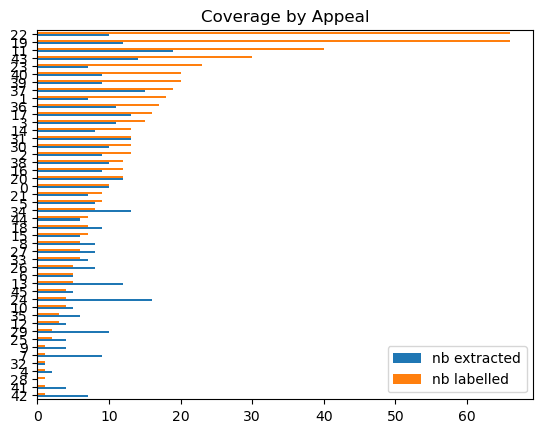

In [9]:
ax = coverage_appeal_df[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh")
ax.set_title("Coverage by Appeal")
fig = ax.get_figure()
#fig.savefig(DATA_FIGURE / f"coverage_by_appeal_{dt.datetime.today().strftime('%d%m%y')}.png", bbox_inches="tight", dpi=300)

In [10]:
## investigate which rows have not been extracted
extracted_labelled_id = matched_df["lab_match_id_sim"]
labelled_df["extracted"] = labelled_df.index.isin(extracted_labelled_id)


In [11]:
labelled_df[labelled_df["appealCode"] == "MDRMZ024"][["extracted", "impactSubtype", "impactValue", "impactUnit", "location", "annotation"]]

,extracted,impactSubtype,impactValue,impactUnit,location,annotation
502,False,Affected People,61165.0,people,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
503,False,Affected People,153000.0,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
504,False,Other Infrastructure Impacts,NaN,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
505,False,Crop Production and Forestry,NaN,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
506,False,Other Service Access Impacts,NaN,None,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
507,False,Crop Production and Forestry,6900.0,km**2 of crop production and forestry,"[Tete, Gaza, Manica, Inhambane]",[1 OPERATION UPDATE Mozambique | Drought Emerg...
508,False,Access to Food,2700000.0,people,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...
509,False,Other Economic and Livelihood Impacts,3.0,\% inflation rate,[],[1 OPERATION UPDATE Mozambique | Drought Emerg...


In [12]:
extracted_df[extracted_df["appealCode"] == "MDRMZ024"][["impactSubtype", "impactValue", "impactUnit", "location", "valueAnnotation"]]

,impactSubtype,impactValue,impactUnit,location,valueAnnotation
63,Affected People,153000.0,people,[],[Tropical Storm Filipo in March2024 impacted15...
64,Affected People,6900.0,km**2 of crop production and forestry,[],"[As of April2024, approximately690,000 hectare..."
65,Affected People,61000.0,people,"[Tete, Gaza, Manica, Inhambane]","[Number of people being assisted:61,165 people..."
66,Crop Production and Forestry,6900.0,km**2 of crop production and forestry,"[Tete, Gaza, Manica, Inhambane]","[As of April2024, approximately690,000 hectare..."
67,Access to Food,2700000.0,people,"[Tete, Gaza, Manica, Inhambane]",[2.7 million people experiencing crisis levels...
68,Other Economic Activity & Livelihood Production,5000000.0,eur,"[Tete, Gaza, Manica, Inhambane]",[Funding requirements (CHF): CHF5 million thro...
69,Other Economic Activity & Livelihood Production,900000.0,chf,[],[Federation-wide DREF amount initially allocat...
70,Crop Production and Forestry,NaN,None,"[Tete, Gaza, Manica, Inhambane]","[Provinces such as Tete, Gaza, Manica, and Inh..."
71,Access to Food,NaN,None,"[Tete, Gaza, Manica, Inhambane]",[high competition for limited income opportuni...
72,Human Health and Wellbeing,NaN,None,"[Tete, Gaza, Manica, Inhambane]",[Mozambique National Institute of Statistics' ...


In [13]:
matched_df[matched_df["appealCode"] == "MDRUG050"][["impactSubtype", "impactSubtype_matched" ,"impactValue", "impactUnit", "impactValue_matched", "impactUnit_matched", "location", "location_matched", "valueAnnotation", "annotation_matched"]]

,impactSubtype,impactSubtype_matched,impactValue,impactUnit,impactValue_matched,impactUnit_matched,location,location_matched,valueAnnotation,annotation_matched
411,Affected People,Affected People,69.0,None,825.0,None,"[Central Region, Eastern Region, Western Regio...",[Bumwoni sub-county],"[In total, by August2024, the floods have affe...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
412,Affected People,Affected People,18.0,None,825.0,None,"[Mbale, Kapchorwa, Bulambuli, Bukedea, Butalej...",[Bumwoni sub-county],"[18,323 people were affected, including thousa...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
413,Affected People,Affected People,11.0,None,825.0,None,[Ntoroko district],[Bumwoni sub-county],"[11,775 individuals (2,355Households) have bee...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
414,Injured People,Injured People,166.0,None,3.0,None,"[Butaleja district, Bukedi Sub County]",[Bumwoni sub-county],[This flooding also significantly affected hea...,"[In Namisindwa, Bumwoni sub-county, a hailstor..."
415,Injured People,Injured People,9.0,None,3.0,None,"[Mbale District, Bukasakya, Bungokho]",[Bumwoni sub-county],[This left109 people homeless and worsened san...,"[In Namisindwa, Bumwoni sub-county, a hailstor..."
416,Injured People,Injured People,6.0,None,3.0,None,"[['[""Bulambuli\'s Bunambutye sub-county""]']]",[Bumwoni sub-county],"[['[""On April3rd, floods hit Bulambuli\'s Buna...","[In Namisindwa, Bumwoni sub-county, a hailstor..."
417,Displaced People,Displaced People,10.0,None,2172.0,people,"[['[\'Central Region\', \'Eastern Region\', \'...",[Ntoroko district],"[In total, by August2024, the floods have affe...","[Further, Ntoroko district witnessed its ever-..."
418,Displaced People,Displaced People,3.0,None,2172.0,people,"[['[\'Bweramule Sub-County\', \'Butungama Sub-...",[Ntoroko district],"[3,080 Families were displaced and rendered ho...","[Further, Ntoroko district witnessed its ever-..."
419,Homeless People,Injured People,1.0,None,3.0,None,"[Sironko District, Bulambuli, Bunambutye sub-c...",[Bumwoni sub-county],[This event also damaged six water facilities ...,"[In Namisindwa, Bumwoni sub-county, a hailstor..."
420,Homeless People,Homeless People,327.0,None,1530.0,people,[Bweramule Sub-County],[Bookies sub-county],"[In Bweramule Sub-County,714 households were a...","[Moreover, floods struck Bookies sub-county, S..."


MDRBD022: 10 extracted, 10 labelled, 1.0 coverage
MDRBJ019: 7 extracted, 18 labelled, 0.3888888888888889 coverage
MDRCM039: 9 extracted, 13 labelled, 0.6923076923076923 coverage
MDRCN006: 11 extracted, 15 labelled, 0.7333333333333333 coverage
MDRCO023: 2 extracted, 1 labelled, 2.0 coverage
MDRDZ011: 8 extracted, 9 labelled, 0.8888888888888888 coverage
MDRGE019: 5 extracted, 5 labelled, 1.0 coverage
MDRGT009: 9 extracted, 1 labelled, 9.0 coverage
MDRGW003: 8 extracted, 6 labelled, 1.3333333333333333 coverage
MDRHU005: 4 extracted, 1 labelled, 4.0 coverage
MDRIQ014: 5 extracted, 4 labelled, 1.25 coverage
MDRKE058: 19 extracted, 40 labelled, 0.475 coverage
MDRMY003: 4 extracted, 3 labelled, 1.3333333333333333 coverage
MDRMZ024: 12 extracted, 5 labelled, 2.4 coverage
MDRNG041: 8 extracted, 13 labelled, 0.6153846153846154 coverage
MDRPH021: 6 extracted, 7 labelled, 0.8571428571428571 coverage
MDRPK026: 9 extracted, 12 labelled, 0.75 coverage
MDRRW022: 13 extracted, 16 labelled, 0.8125 cover

Text(0.5, 0.98, 'Coverage by Appeal')

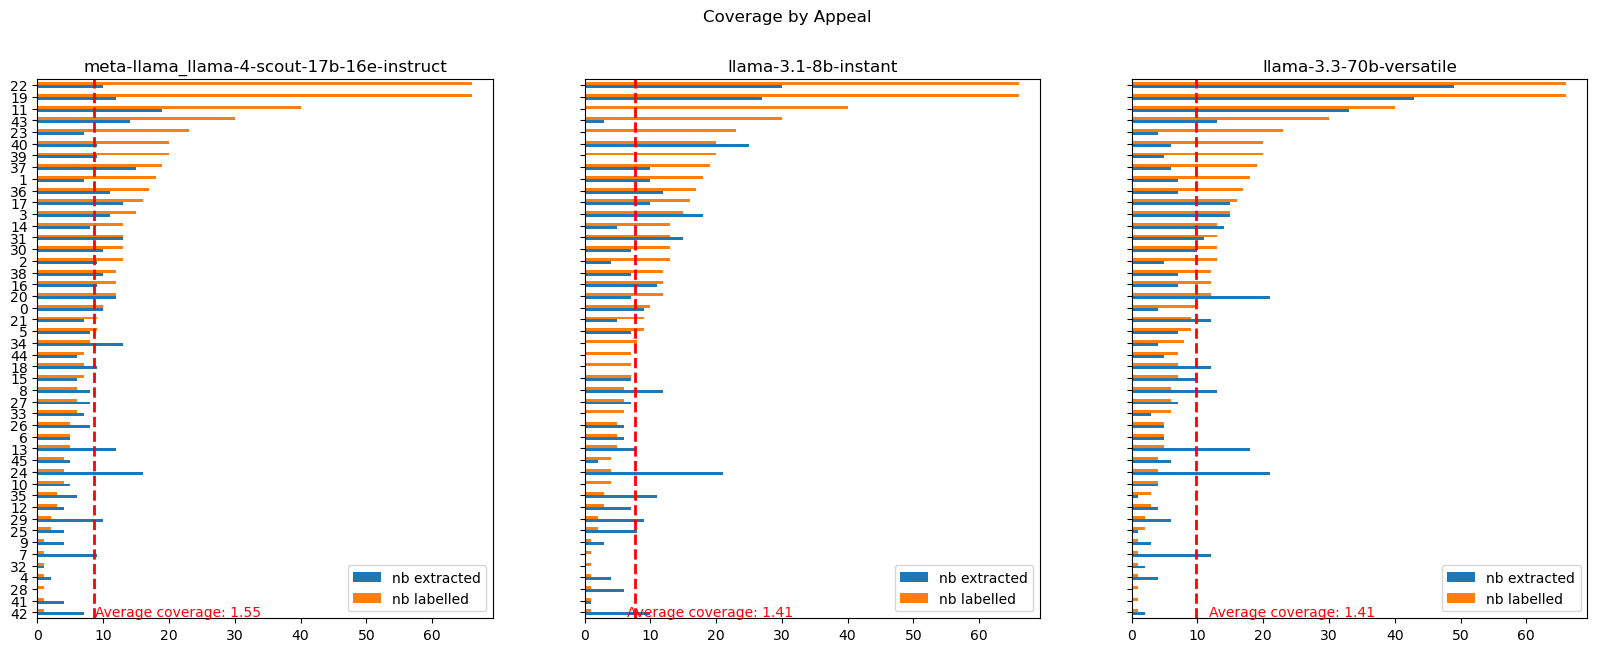

In [14]:
# compare different models
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
res_savename_ext1 = f"post_processed_labelled_reports_{models[0]}_v230925"
res_savename_ext2 = f"post_processed_labelled_reports_{models[1]}_v250925"
res_savename_ext3 = f"post_processed_labelled_reports_{models[2]}_v250925"

#load geocoded data
extracted_df1 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext1+".csv"))
extracted_df2 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext2+".csv"))
extracted_df3 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext3+".csv"))

extracted_df1["quanti"] = extracted_df1["impactValue"].notnull()
extracted_df2["quanti"] = extracted_df2["impactValue"].notnull()
extracted_df3["quanti"] = extracted_df3["impactValue"].notnull()
labelled_df["quanti"] = labelled_df["impactValue"].notnull()

coverage_appeal_df1 = make_coverage_appeal_df(extracted_df1, labelled_df)
coverage_appeal_df2 = make_coverage_appeal_df(extracted_df2, labelled_df)
coverage_appeal_df3 = make_coverage_appeal_df(extracted_df3, labelled_df)

fig, axes = plt.subplots(1, 3 ,figsize=(20,7), sharey=True)
coverage_appeal_df1[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh", ax=axes[0])
coverage_appeal_df2[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh", ax=axes[1])
coverage_appeal_df3[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).plot(kind="barh", ax=axes[2])

#add averages
axes[0].axvline(coverage_appeal_df1["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[1].axvline(coverage_appeal_df2["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[2].axvline(coverage_appeal_df3["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)

axes[0].text(coverage_appeal_df1["nb extracted"].mean()*2.5, 0, f"Average coverage: {coverage_appeal_df1['coverage'].mean():.2f}", color="red", ha="center", va="center")
axes[1].text(coverage_appeal_df2["nb extracted"].mean()*2.5, 0, f"Average coverage: {coverage_appeal_df2['coverage'].mean():.2f}", color="red", ha="center", va="center")
axes[2].text(coverage_appeal_df3["nb extracted"].mean()*2.5, 0, f"Average coverage: {coverage_appeal_df3['coverage'].mean():.2f}", color="red", ha="center", va="center")

axes[0].set_title(models[0])
axes[1].set_title(models[1])
axes[2].set_title(models[2])

fig.suptitle("Coverage by Appeal")
#fig.savefig(DATA_FIGURE / f"coverage_by_appeal_{dt.datetime.today().strftime('%d%m%y')}.png", bbox_inches="tight", dpi=300)

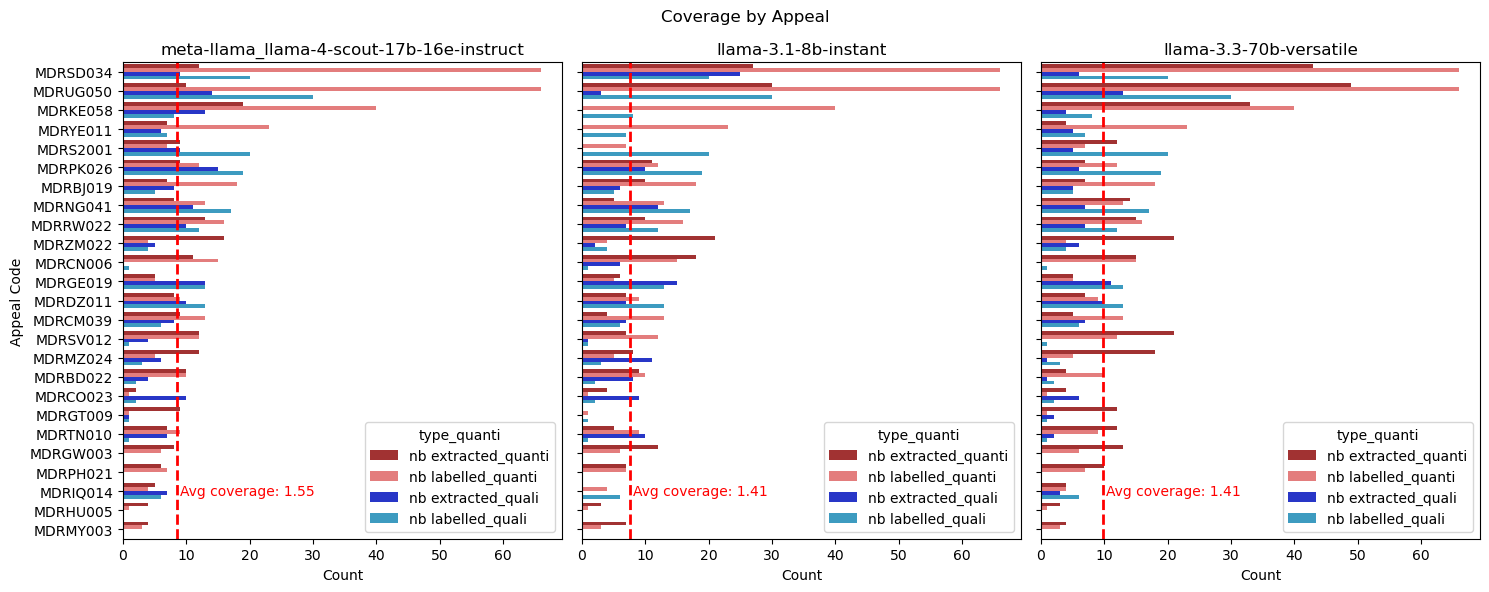

In [15]:
import seaborn as sns

def plot_coverage_split_both(coverage_df, model_name, ax):
    # melt to long format
    df_melt = coverage_df.melt(
        id_vars=["appealCode", "quanti"],
        value_vars=["nb extracted", "nb labelled"],
        var_name="type", value_name="count"
    )

    # combine type + quanti into a single hue
    df_melt["type_quanti"] = df_melt["type"] + "_" + df_melt["quanti"].astype(str)

    # barplot with both factors in hue
    sns.barplot(
        data=df_melt.sort_values("count", ascending=False),
        x="count", y="appealCode",
        hue="type_quanti",
        hue_order=["nb extracted_quanti", "nb labelled_quanti", "nb extracted_quali", "nb labelled_quali"],
        palette=["#b41f1f", "#f46c6c", "#0e20e1", "#27a4d6"],ax=ax
    )

    # add average coverage line
    ax.axvline(coverage_df["nb extracted"].mean(), color="red", linestyle="--", linewidth=2)
    ax.text(
        coverage_df["nb extracted"].mean()*1.05,
        22,
        f"Avg coverage: {coverage_df['coverage'].mean():.2f}",
        color="red", ha="left", va="center"
    )

    ax.set_title(model_name)
    ax.set_xlabel("Count")
    ax.set_ylabel("Appeal Code")

# ---- plot all 3 models ----
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

plot_coverage_split_both(coverage_appeal_df1, models[0], axes[0])
plot_coverage_split_both(coverage_appeal_df2, models[1], axes[1])
plot_coverage_split_both(coverage_appeal_df3, models[2], axes[2])

fig.suptitle("Coverage by Appeal")
plt.tight_layout()


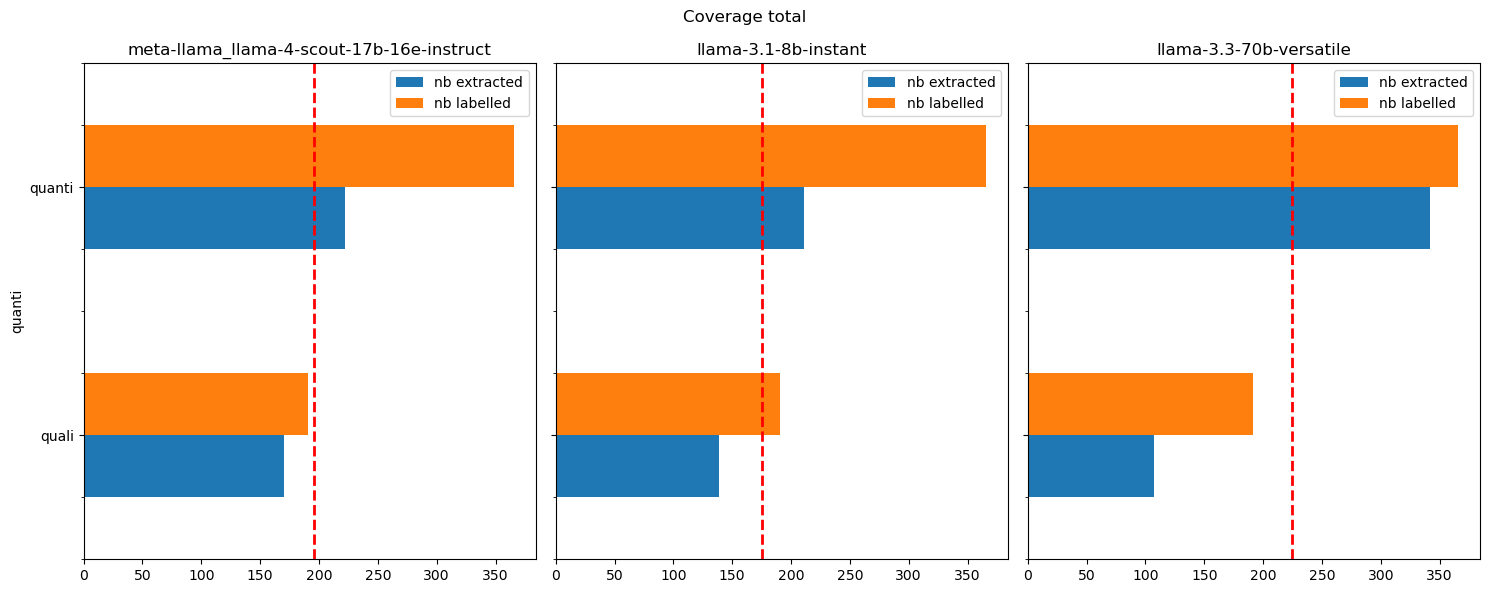

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

sumed_appeal1 = coverage_appeal_df1.groupby("quanti")[["nb extracted", "nb labelled"]].sum()
sumed_appeal1.plot(kind="barh", stacked=False, ax=axes[0]) # models[0], axes[0])
axes[0].axvline(sumed_appeal1["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[0].set_title(models[0])

sumed_appeal2 = coverage_appeal_df2.groupby("quanti")[["nb extracted", "nb labelled"]].sum()
sumed_appeal2.plot(kind="barh", stacked=False, ax=axes[1]) # models[1], axes[1])
axes[1].axvline(sumed_appeal2["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[1].set_title(models[1])

sumed_appeal3 = coverage_appeal_df3.groupby("quanti")[["nb extracted", "nb labelled"]].sum()
sumed_appeal3.plot(kind="barh", stacked=False, ax=axes[2]) # models[2], axes[2])
axes[2].axvline(sumed_appeal3["nb extracted"].mean(), color="red", linestyle="dashed", linewidth=2)
axes[2].set_title(models[2])
#plot_coverage_split_both(coverage_appeal_df2, models[1], axes[1])
#plot_coverage_split_both(coverage_appeal_df3, models[2], axes[2])

fig.suptitle("Coverage total")
plt.tight_layout()


## Coverage with accuracy

In [17]:
#load data extracted for a specific model

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
res_savename_ext = f"post_processed_new_unit_std_labelled_reports_turnoff_subtype_val_{key}_v131025"
#f"post_processed_labelled_reports_{key}_v250925"
#f"post_processed_flags_labelled_reports_{key}_v250925"
#load data (labelled)
res_savename_lab = "post_processed_new_unit_std_labelled_reports_impacts_all_v111025"

split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix2 = suffix + "_v171025"
suffix3 = suffix + "_v171025"
#load geocoded data
extracted_df = gpd.read_file(DATA_OUT_PROC / (res_savename_ext+suffix2+".gpkg"))
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix3+".gpkg"))
#load corresponding matched data
filename_match = f"matched_data_ws2-geo-valuepre-loose-nans_{res_savename_ext}"
matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match + ".feather"))

DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]
keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
for name in ["matched_df", "extracted_df", "labelled_df"]:
    df = locals()[name]
    df["quanti"] = df["impactValue"].notnull()
    df.loc[df["quanti"],"quanti"] = "quanti"
    df.loc[df["quanti"]==False,"quanti"] = "quali"
    df = df.set_crs(DEF_CRS_EPSG, allow_override=True)
    df = df[df["appealCode"].isin(keep_appeals)]
    locals()[name] = df  # assign back

#compute metrics
matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_96059/3642997263.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_96059/3642997263.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[df["quanti"],"quanti"] = "quanti"
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_96059/3642997263.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'quanti' has dtype incompatible with bool, please explicitly cast to a compatible dtype fir

In [18]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v240925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [19]:

def filter_matches(matched_df, value_error_th=0.05, sim_th=0.6, match_cat=["impactSubtype"]):
    """Filter matches based on value error threshold for quantitative and similarity threshold for qualitative"""
    #filter matches
    matched_df_filter_qt = matched_df.copy()
    matched_df_filter_qt = matched_df_filter_qt[(matched_df_filter_qt["match_sim"] >= sim_th) & (matched_df_filter_qt["impactValue_error"] <= value_error_th) & (matched_df_filter_qt["quanti"]=="quanti")]
    matched_df_filter_ql = matched_df.copy()
    matched_df_filter_ql = matched_df_filter_ql[(matched_df_filter_ql["match_sim"] >= sim_th) & (matched_df_filter_ql["quanti"]=="quali")]
    if match_cat:
        matched_df_filter_ql = pd.concat([matched_df_filter_ql.query(f"{cat} == {cat}_matched").dropna(how="all",axis=0) for cat in match_cat]).sort_index()
    return pd.concat([matched_df_filter_qt, matched_df_filter_ql], axis=0)

def make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key="appeal", keep_vars=[]):
    """Make coverage df filtering matches by accuracy and grouped by group_key"""

    df_list = []
    for qq in ["quanti", "quali"]:
        labelled_dfq = labelled_df[labelled_df["quanti"]==qq]
        extracted_dfq = extracted_df[extracted_df["quanti"]==qq]
        matched_df_filterq = matched_df_filter[matched_df_filter["quanti"]==qq]
        metrics_by_key = {}
        if group_key == None:
            metrics_by_key["nb labelled"] = len(labelled_dfq)
            metrics_by_key["nb extracted"] = len(extracted_dfq)
            metrics_by_key["coverage"] = 100*len(extracted_dfq)/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb matches"] = matched_df_filterq["lab_match_id_sim"].nunique()
            metrics_by_key["coverage matches"] = 100*metrics_by_key["nb matches"]/len(labelled_dfq) if len(labelled_dfq) > 0 else np.nan
            metrics_by_key["nb garbage"] = max(0,len(extracted_dfq) - metrics_by_key["nb matches"])
            metrics_by_key["garbage"] = 100*(metrics_by_key["nb garbage"] / len(extracted_dfq)) if len(extracted_dfq) > 0 else 0
            metrics_by_key["quanti"] = qq

            print(f'Overall average {qq}: {metrics_by_key["nb extracted"]} extracted, {metrics_by_key["nb labelled"]} labelled, {metrics_by_key["nb matches"]} correct matches, {metrics_by_key["nb garbage"]} garbage matches')
            df_list.append(pd.DataFrame(metrics_by_key, index=[0]))
        else:
            for group_id, group_lab in labelled_dfq.groupby(group_key):
                group_ext = extracted_dfq[extracted_dfq[group_key] == group_id]
                group_ext_match = matched_df_filterq[matched_df_filterq[group_key] == group_id]
                metrics_by_key["nb labelled"] = len(group_lab)
                metrics_by_key["nb extracted"] = len(group_ext)
                metrics_by_key["coverage"] = 100*len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb matches"] = group_ext_match["lab_match_id_sim"].nunique()
                metrics_by_key["coverage matches"] = 100*metrics_by_key["nb matches"]/len(group_lab) if len(group_lab) > 0 else np.nan
                metrics_by_key["nb garbage"] = max(0,len(group_ext) - metrics_by_key["nb matches"])
                metrics_by_key["garbage"] = 100*(metrics_by_key["nb garbage"] / len(group_ext)) if len(group_ext) > 0 else 0
                metrics_by_key["quanti"] = qq
                if len(keep_vars):
                    for keep_var in keep_vars:
                        if keep_var != group_key:
                            metrics_by_key[keep_var] = group_ext[keep_var].head(1).values[0]
                df_list.append(pd.DataFrame(metrics_by_key, index=[group_id]))
    return pd.concat(df_list)

def filter_by_flags(df, flag_filters=list):
    for flt_flag in flag_filters:
        df = df[~df[flt_flag]]
    return df

In [20]:
#define threshold above which we consider a match
value_error_th = 0.1
sim_th = 0.6
filter_flags = ["flag_unit_nonstd", "flag_percent"]#["flag_unit_nonstd"
extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode", keep_vars=["appealType", "reportSize", "reportDate"]).reset_index(drop=False, names=["appealCode"])
coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype").reset_index(drop=False, names=["impactSubtype"])

Overall average quanti: 164 extracted, 319 labelled, 112 correct matches, 52 garbage matches
Overall average quali: 164 extracted, 169 labelled, 55 correct matches, 109 garbage matches


In [21]:
from matplotlib.patches import bbox_artist
from matplotlib.pyplot import subplot

def plot_coverage_match_v2(df, subplot_col, hue_col, yvar, xlabel="%", value_col="value",palette=None, add_avg=True):
    subplot_vars = df[subplot_col].unique()
    hue_vars = df[hue_col].unique()
    if not palette:
        palette = sns.color_palette("colorblind", len(hue_vars))
    fig, ax = plt.subplots(1, len(subplot_vars), figsize=(15, 8), sharey=True)
    for i, val in enumerate(subplot_vars):
        val_df = df[df[subplot_col] == val]
        ipal = palette[2*i:2*(i+1)]
        sns.barplot(
            data=val_df,
            x=value_col, y=yvar,
            hue=hue_col,
            #hue_order=hue_order,
            palette=ipal,
            ax=ax[i]
        )

        #add average coverage line
        if add_avg:
            for j, var in enumerate(hue_vars):
                mean_val = val_df[val_df[hue_col] == var].groupby(yvar)[value_col].mean().mean()
                #mean_val = df[(df[yvar] == "Overall average") & (df[hue_col] == var) & (df[subplot_col] == val)][value_col].values[0]
                ax[i].axvline(mean_val, color=ipal[j], linestyle="--", linewidth=2)
                ax[i].text(
                    mean_val, 2+2*j, f"Average {var}: {mean_val:.2f}"
                    , color=ipal[j], ha="left", va="center", backgroundcolor="white"
                )
        ax[i].set_title(val)
        ax[i].set_ylabel(yvar)
        ax[i].set_xlabel(xlabel)
        ax[i].legend(loc="lower right")
    return fig, ax


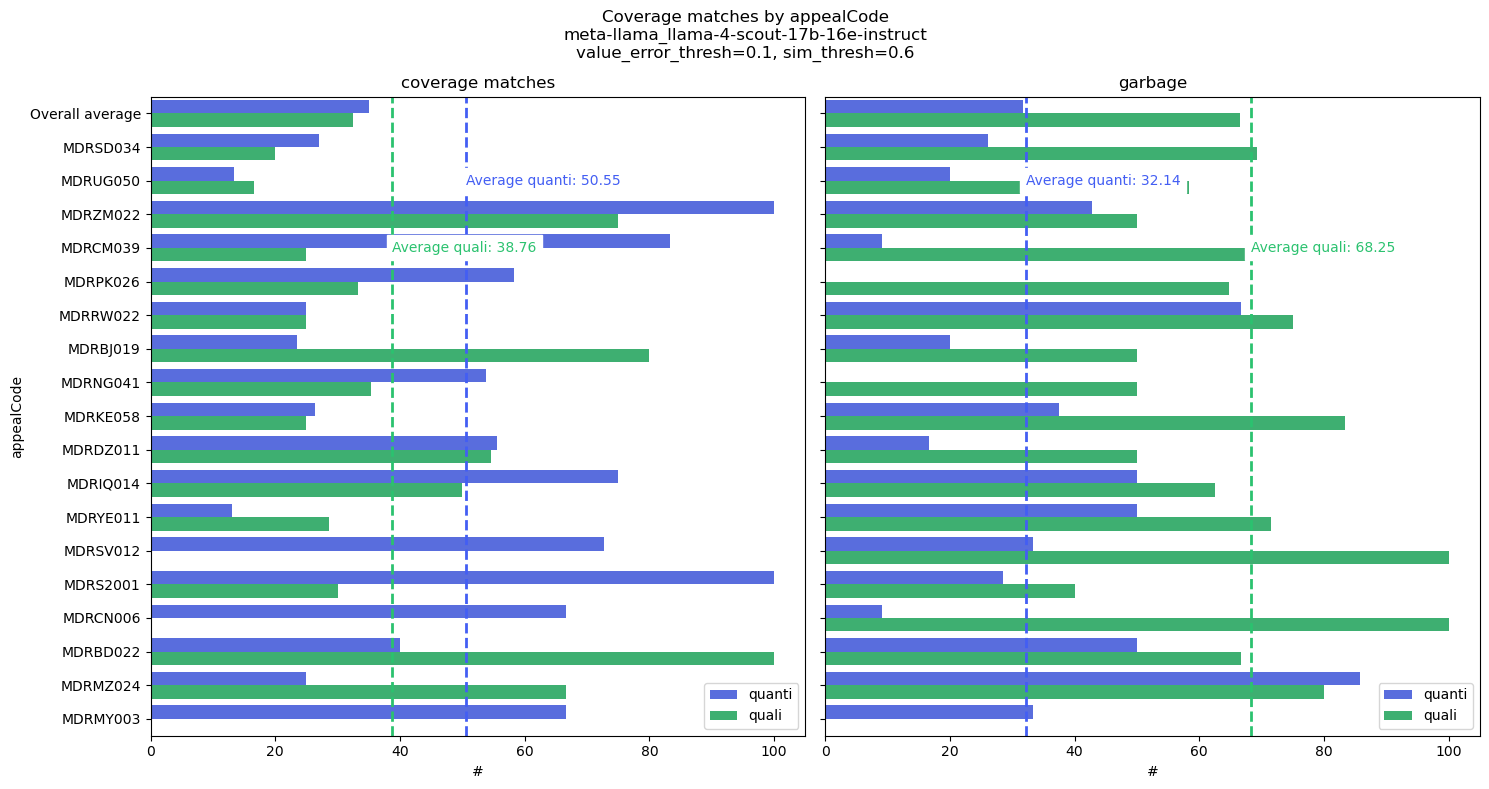

In [23]:
value_vars = ["coverage matches", "garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="appealCode"
add_avg = True
if yvar == "appealCode":
    coverage_df_match_yvar = coverage_df_match_appeal
    #sort by to look for trends
    size_index = extracted_df.groupby("appealCode").head(1).sort_values("reportSize", ascending=False)["appealCode"]
    coverage_df_match_yvar["appealCode"] = pd.Categorical(coverage_df_match_yvar["appealCode"], categories=size_index, ordered=True)
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("appealCode") #sort by size
    plot_df = coverage_df_match_yvar.melt(id_vars=[yvar,"reportSize", "reportDate", "appealType", "quanti"], value_vars=value_vars, var_name="match", value_name="value")

elif yvar == "impactSubtype":
    coverage_df_match_yvar = coverage_df_match_subtype
    coverage_df_match_yvar = coverage_df_match_yvar.sort_values("nb labelled", ascending=False) #sort by nb labelled
    plot_df = coverage_df_match_yvar.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
if add_avg:
    average_df_match = coverage_df_match.melt(id_vars=["quanti"], value_vars=value_vars, var_name="match", value_name="value")
    average_df_match[yvar] ="Overall average"
    plot_df = pd.concat([average_df_match, plot_df], axis=0)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]
fig, axes =plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
[ax.set_xlabel(label) for ax in axes]
fig.suptitle(f"Coverage matches by {yvar}\n{key}\nvalue_error_thresh={value_error_th}, sim_thresh={sim_th}")
fig.tight_layout()
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_{subplot_col}_vth-{value_error_th}_sth-{sim_th}_flt-{'_'.join(filter_flags)}_{filename_match}.png", bbox_inches="tight", dpi=300)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_77998/1920059522.py:13: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_77998/1920059522.py:13: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(


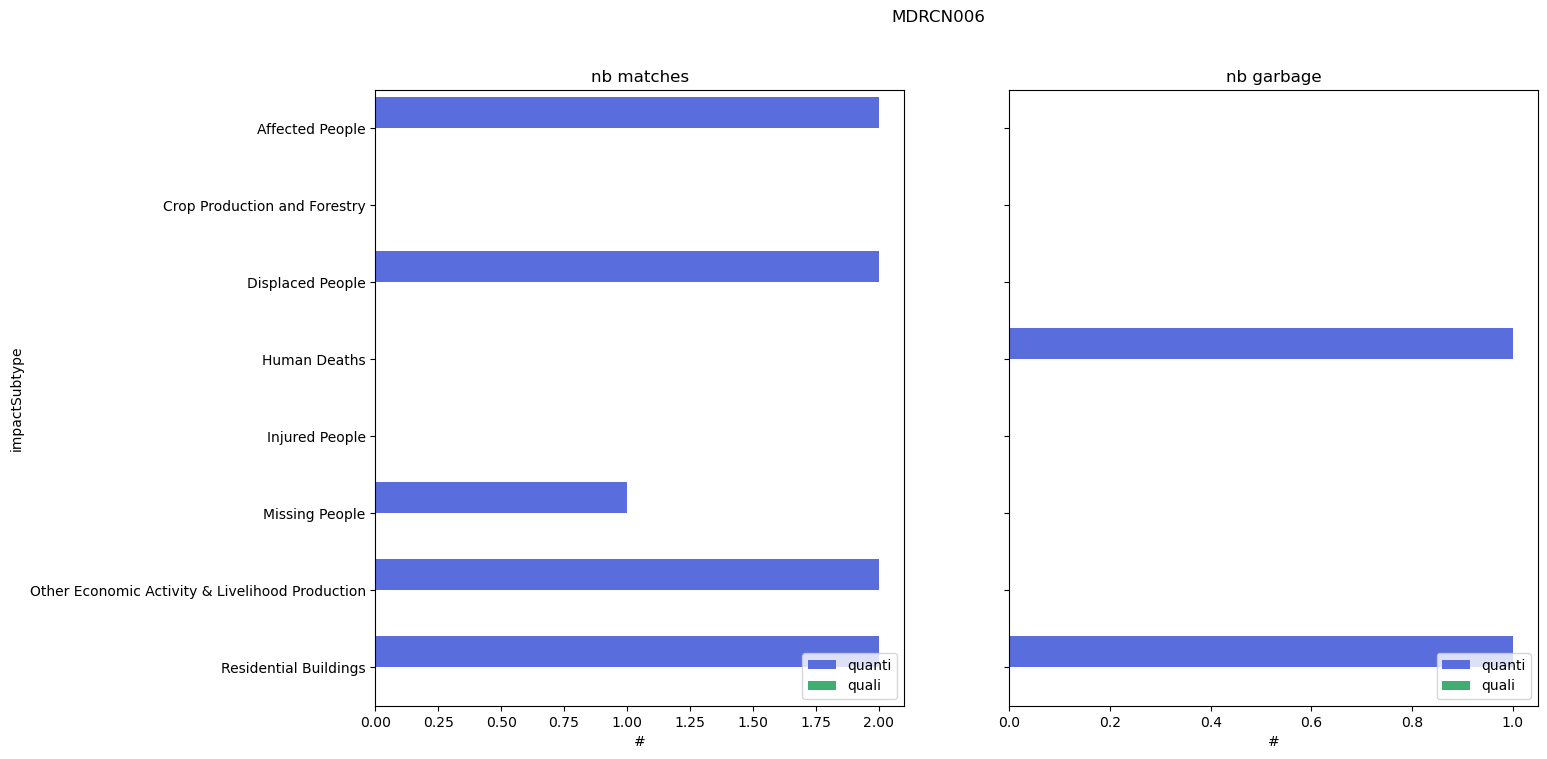

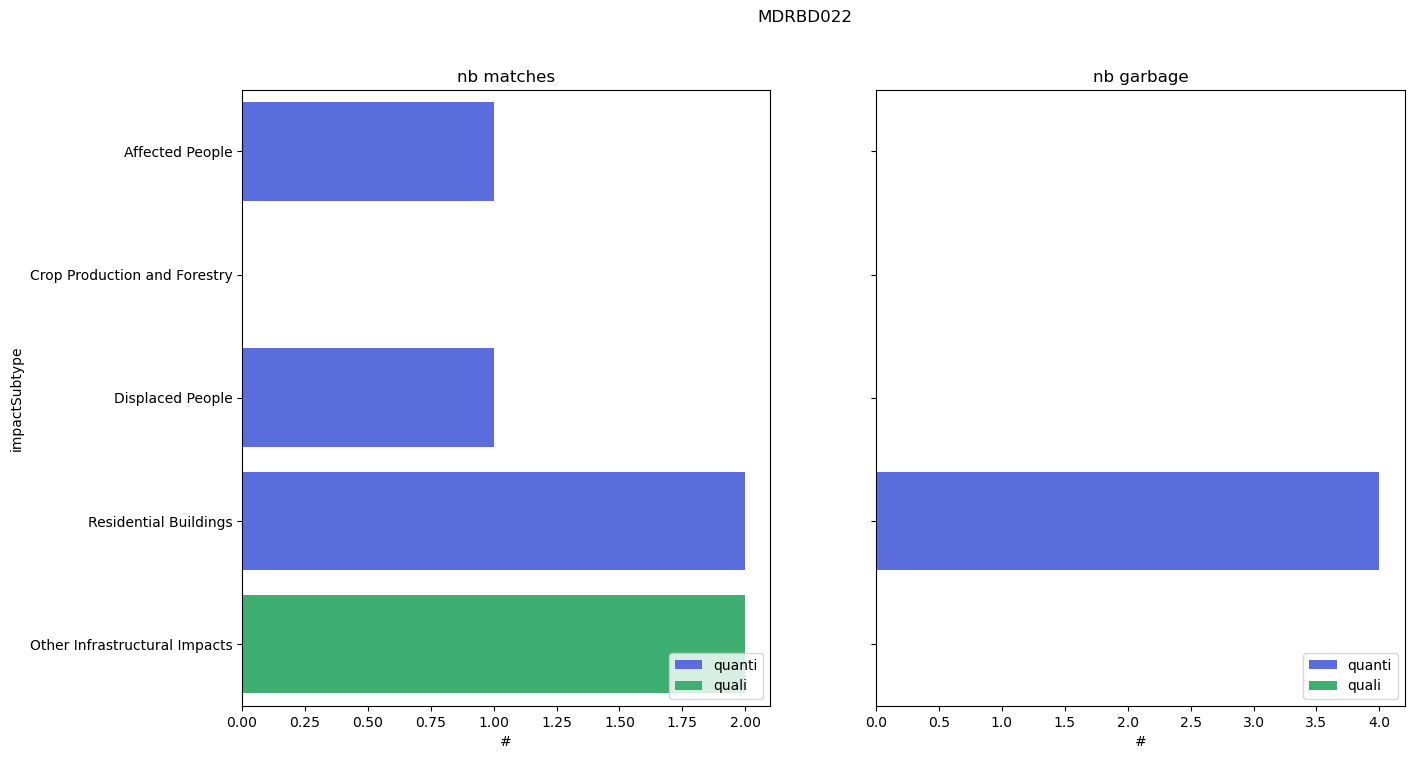

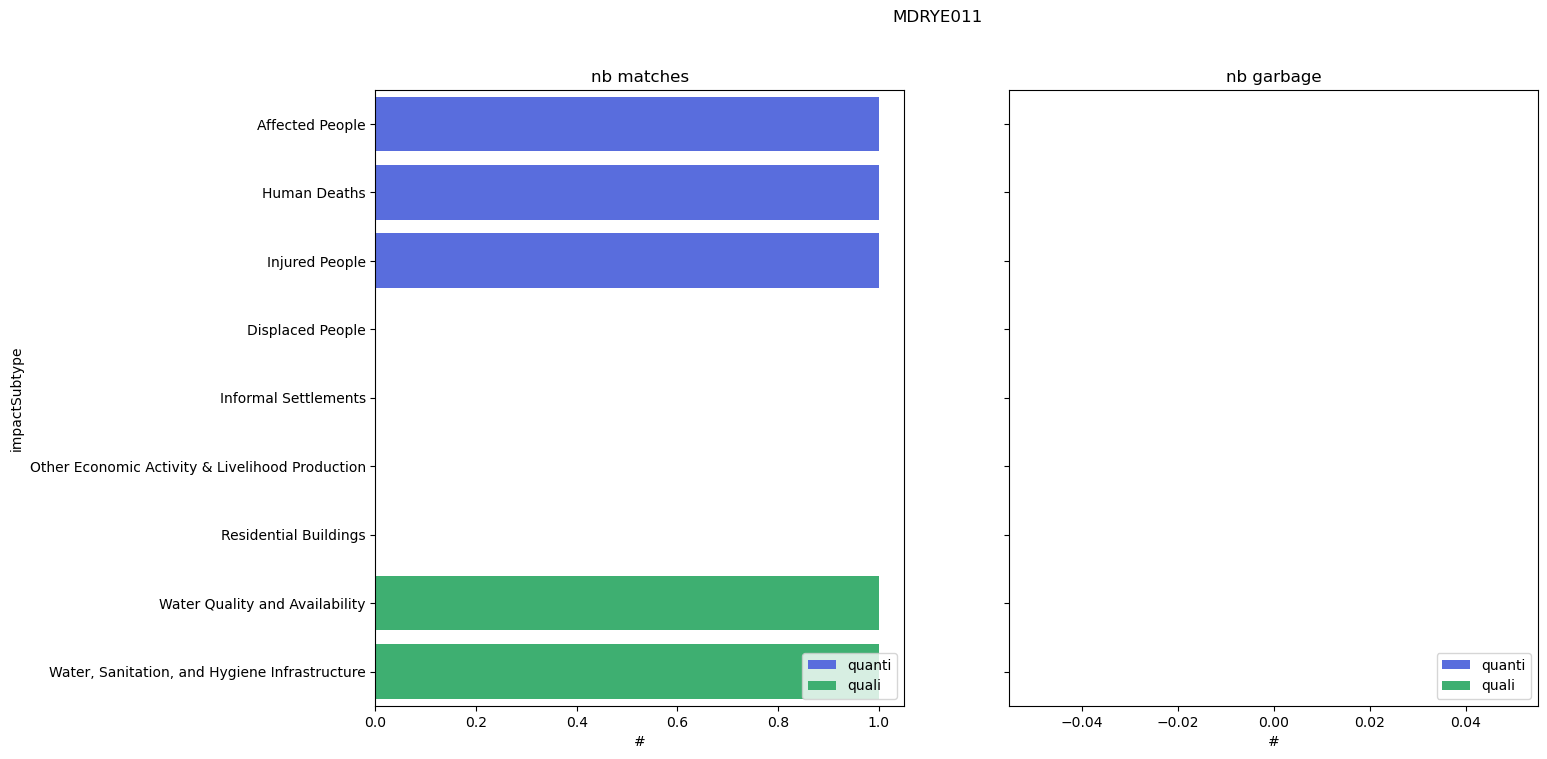

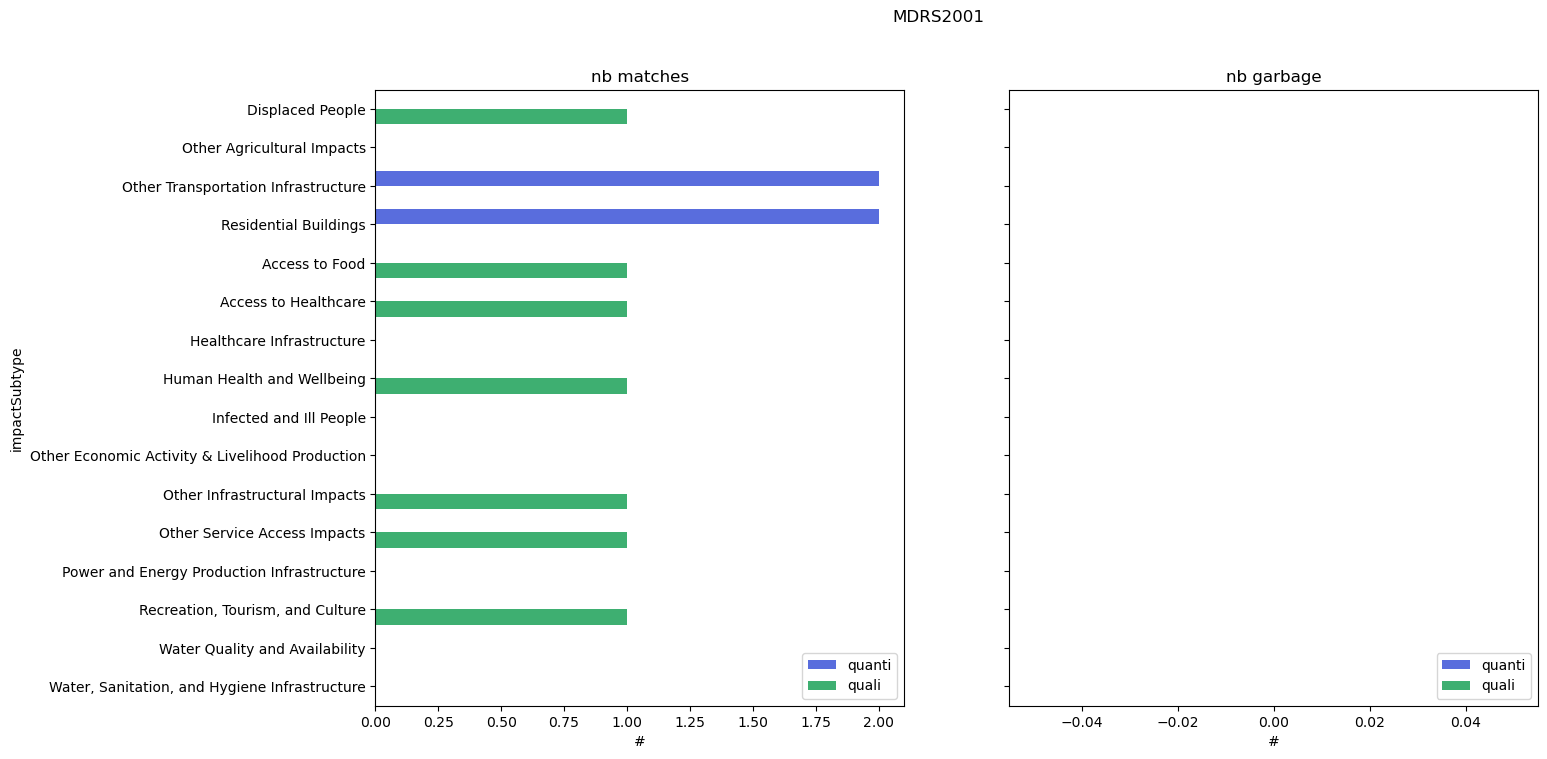

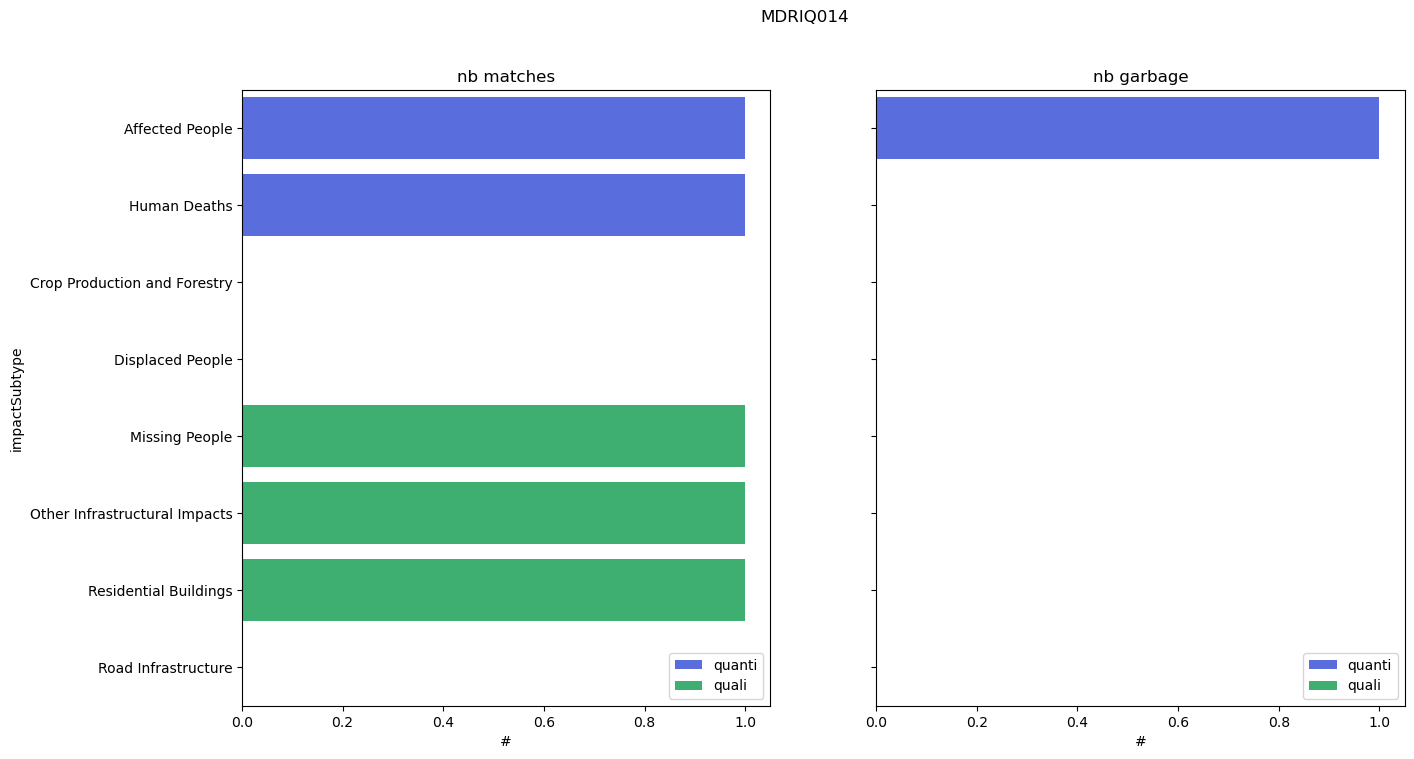

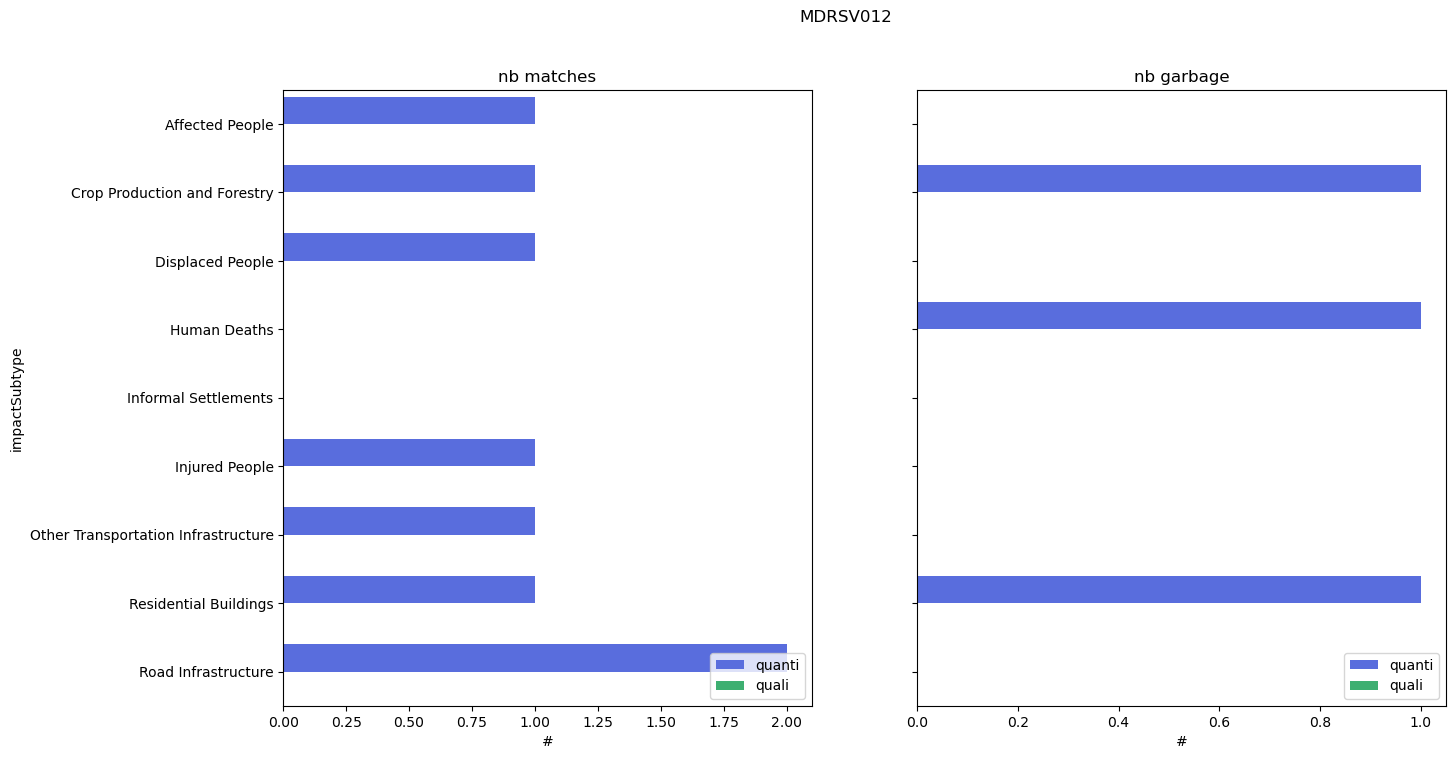

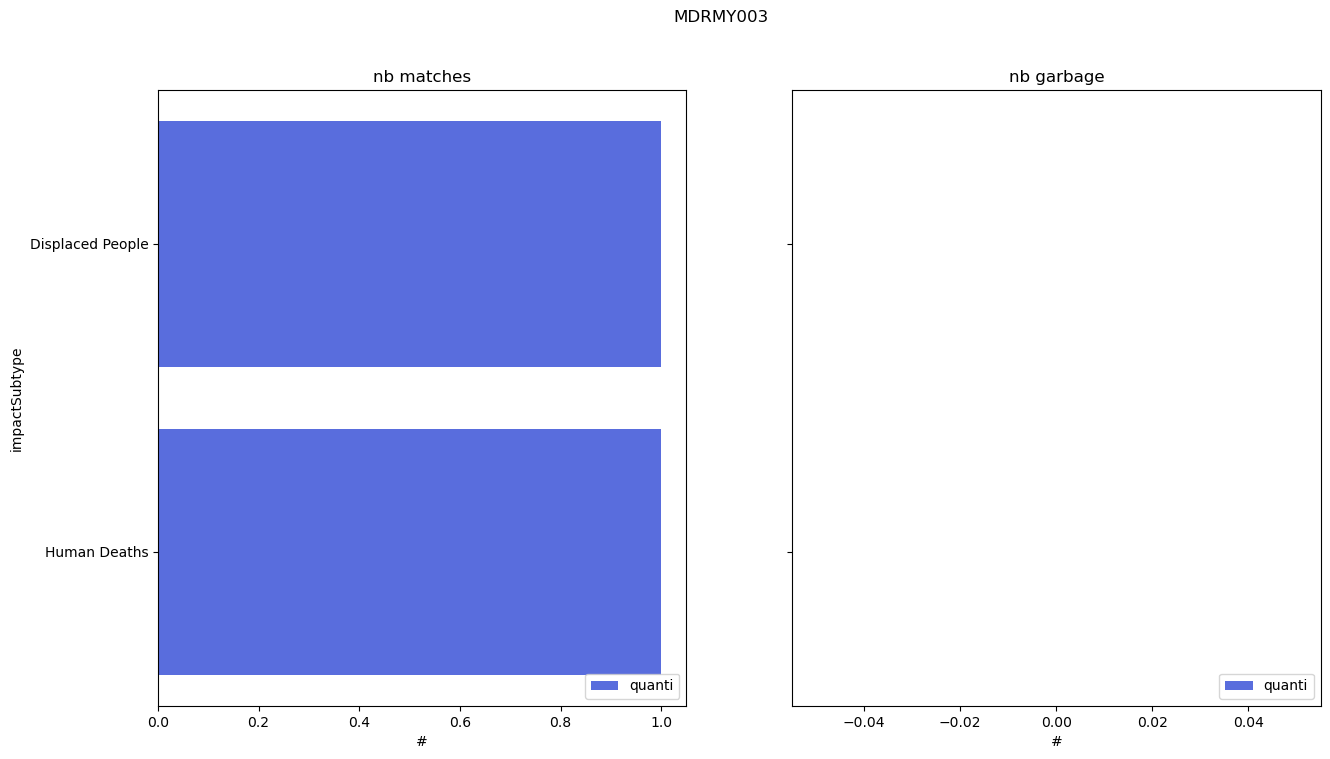

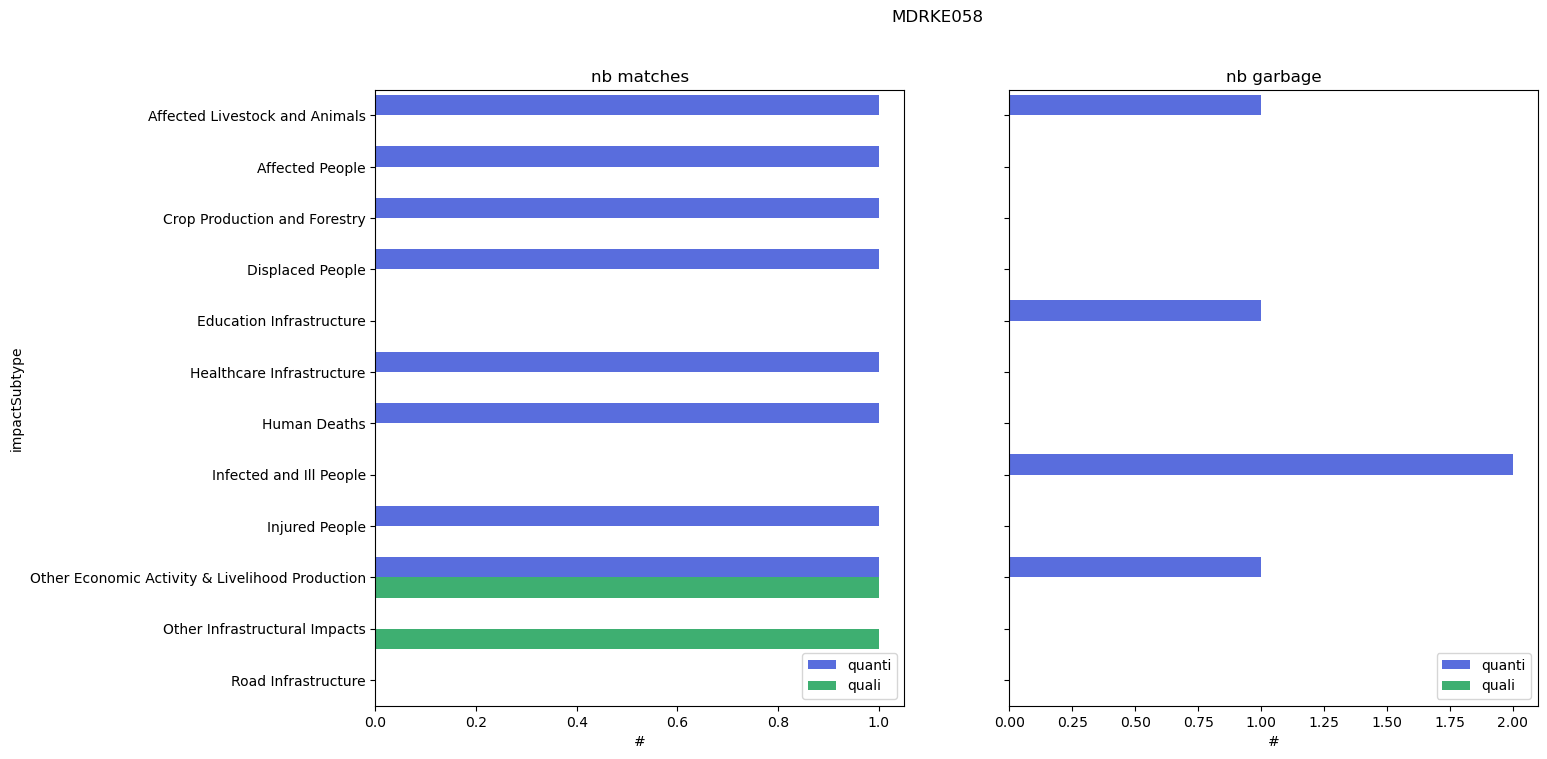

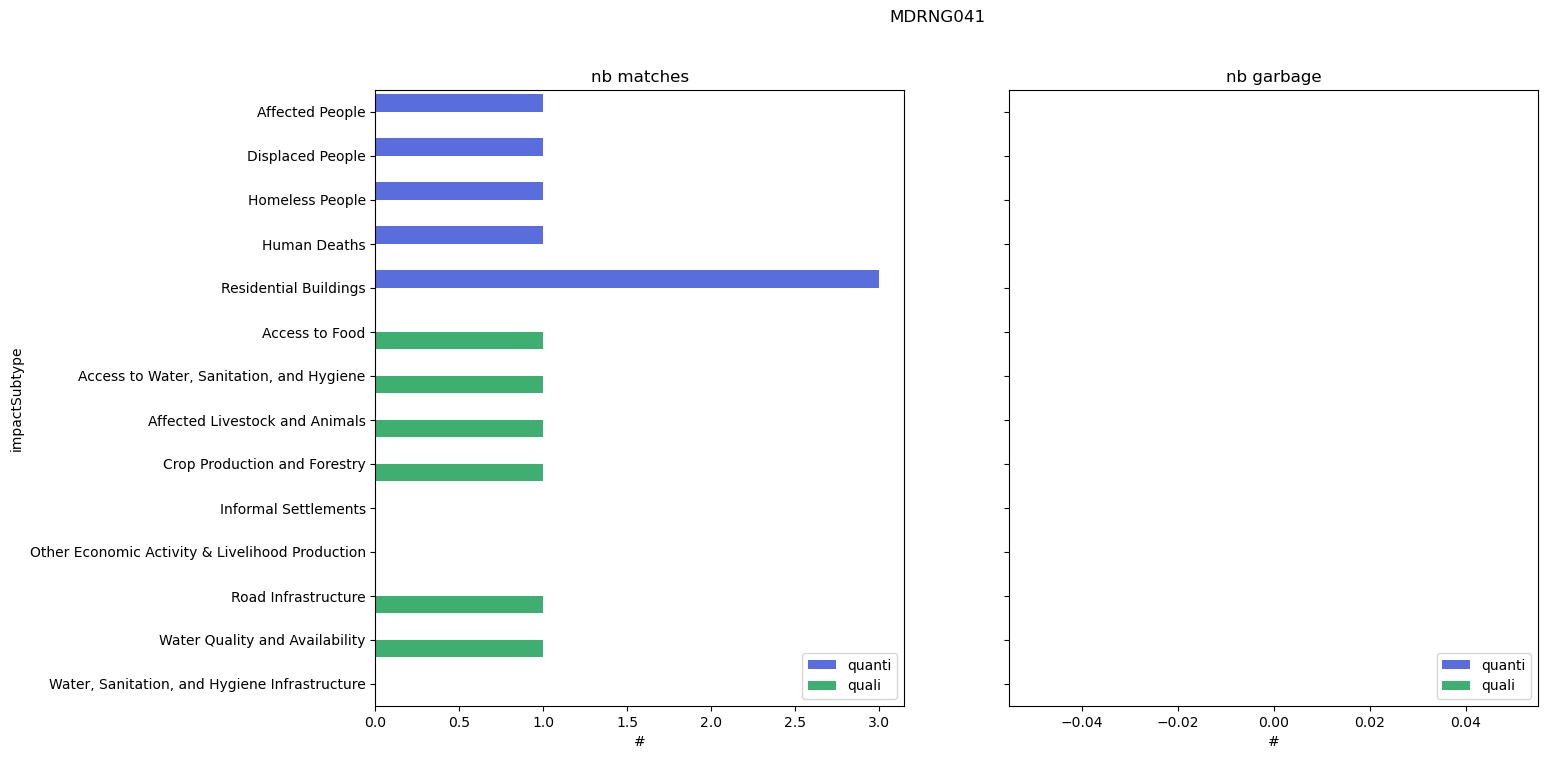

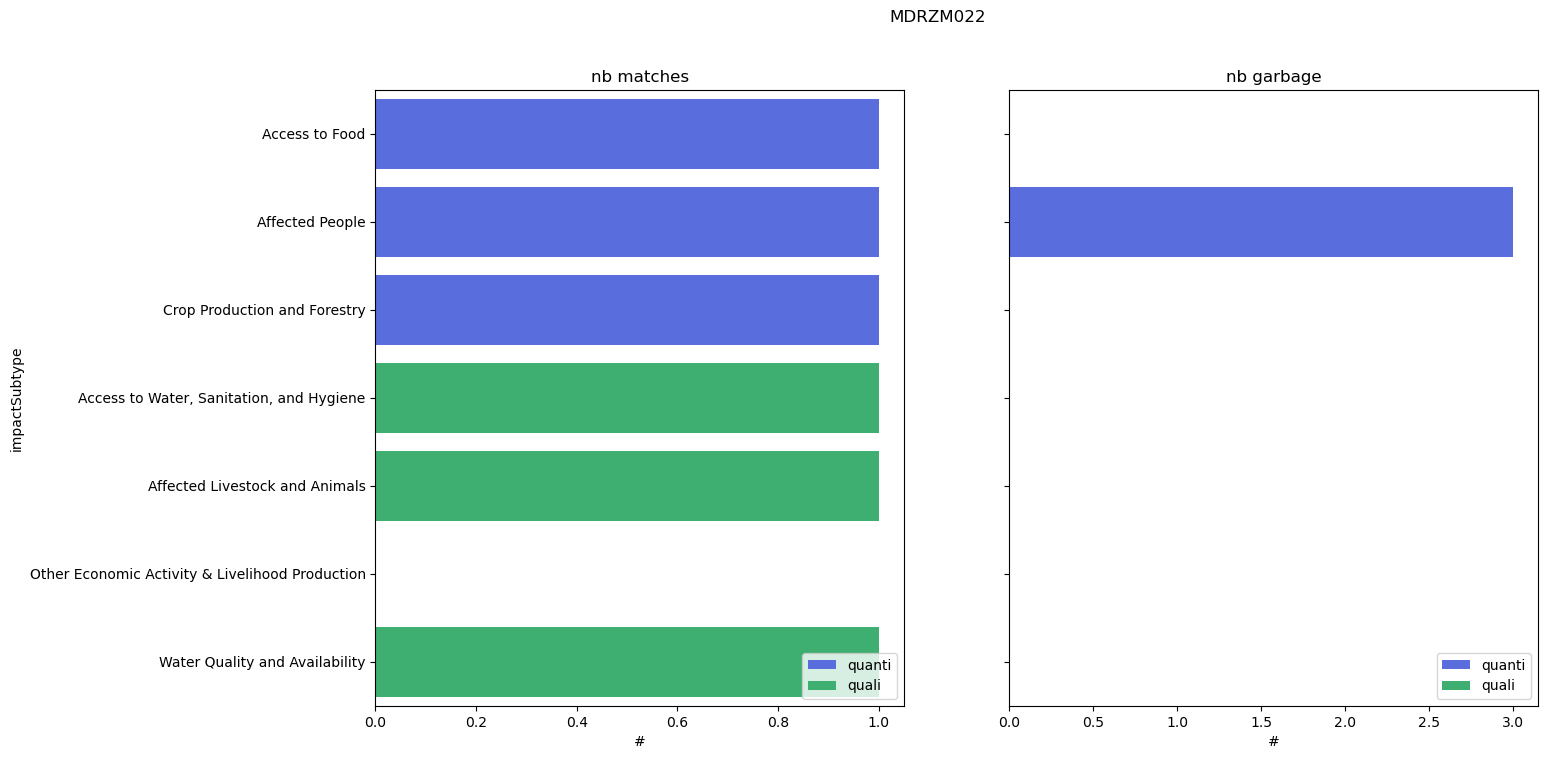

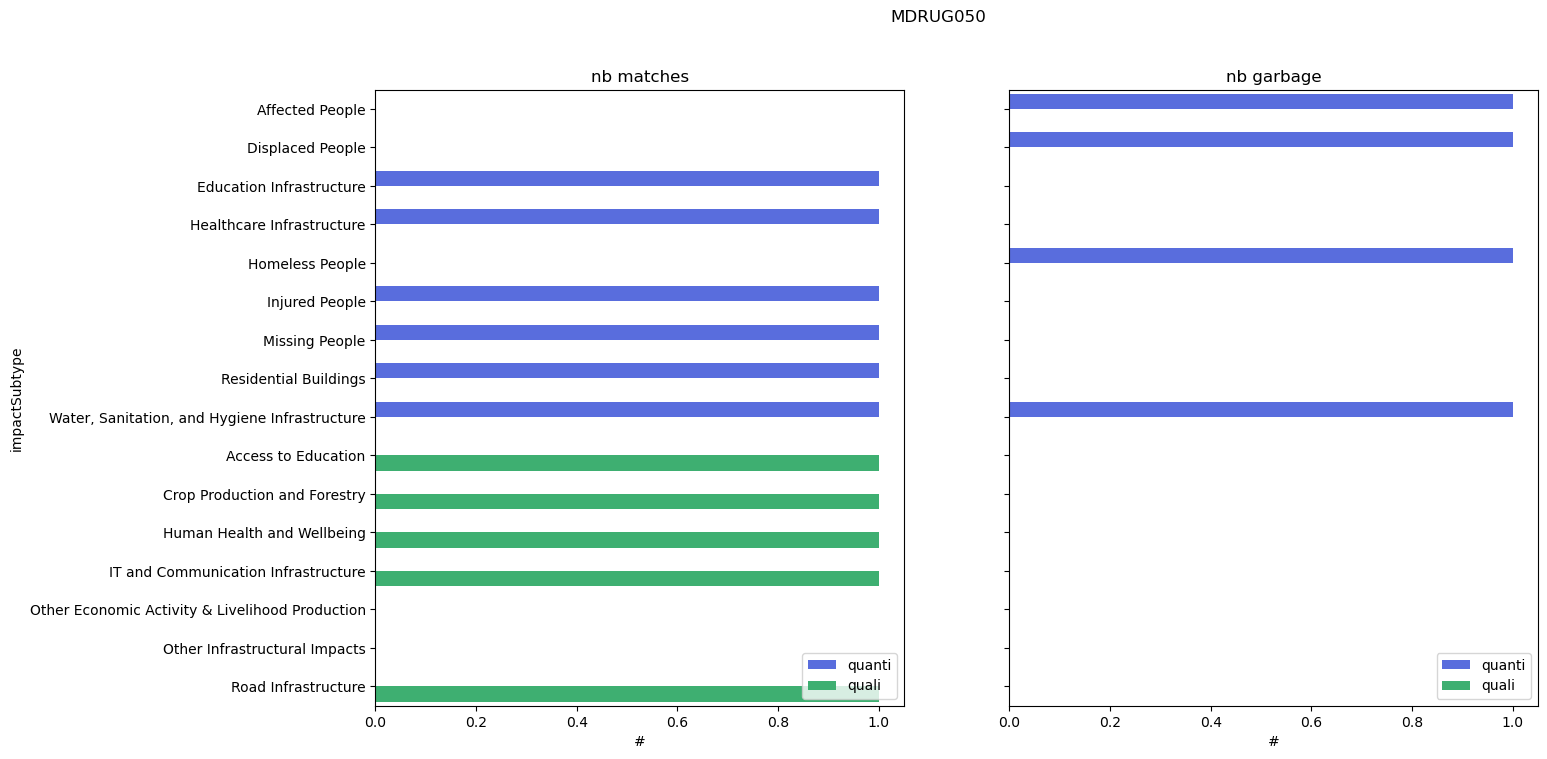

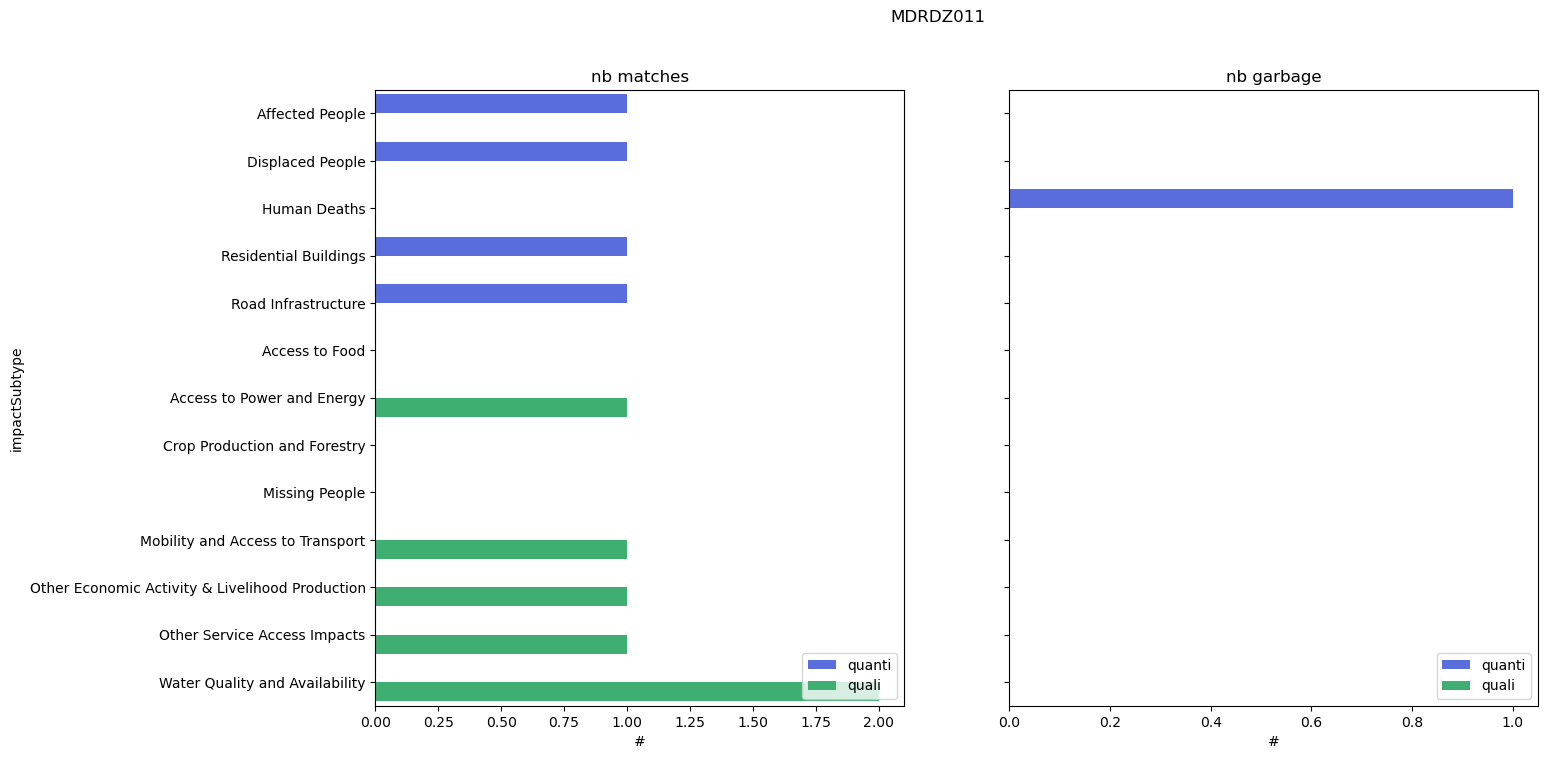

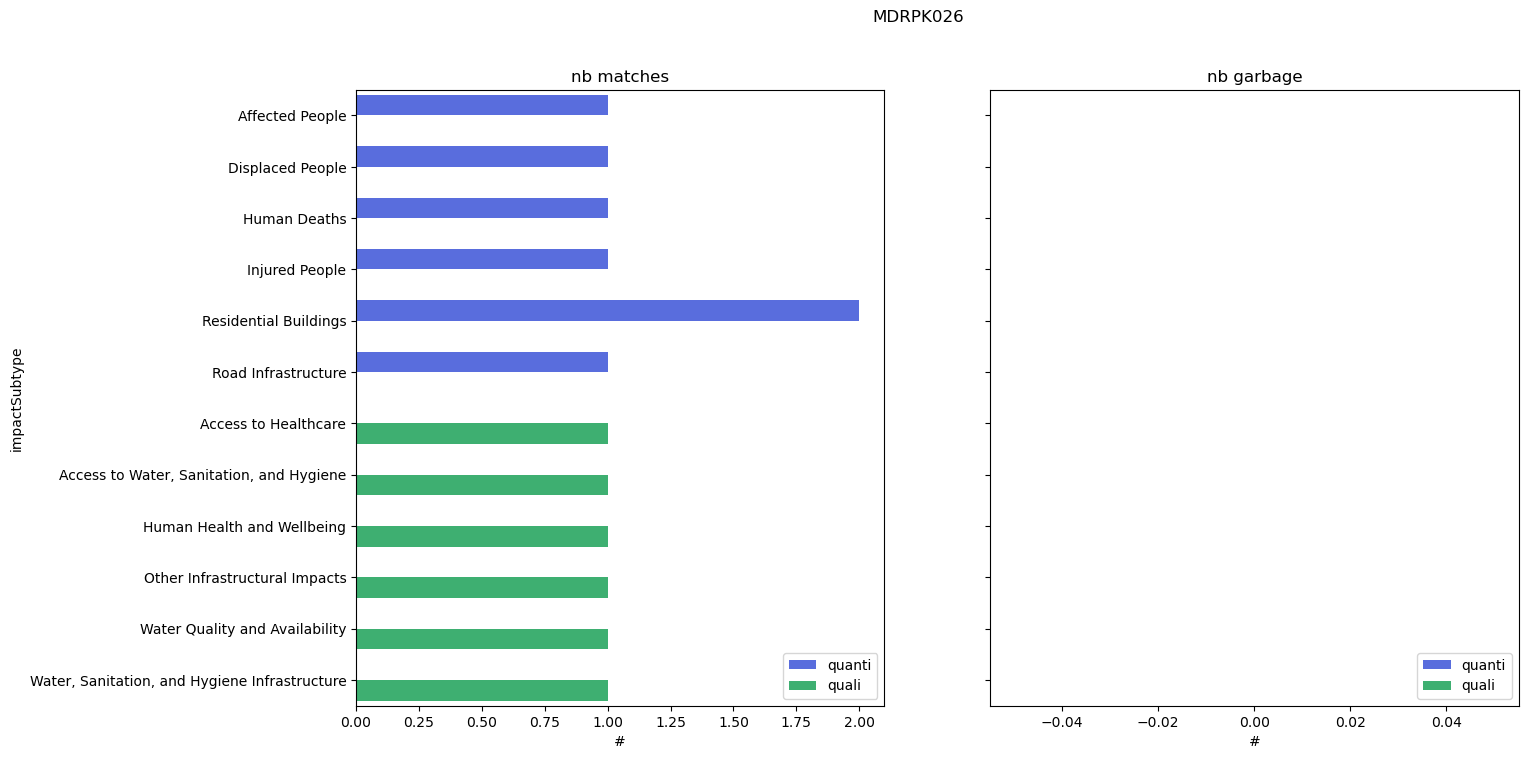

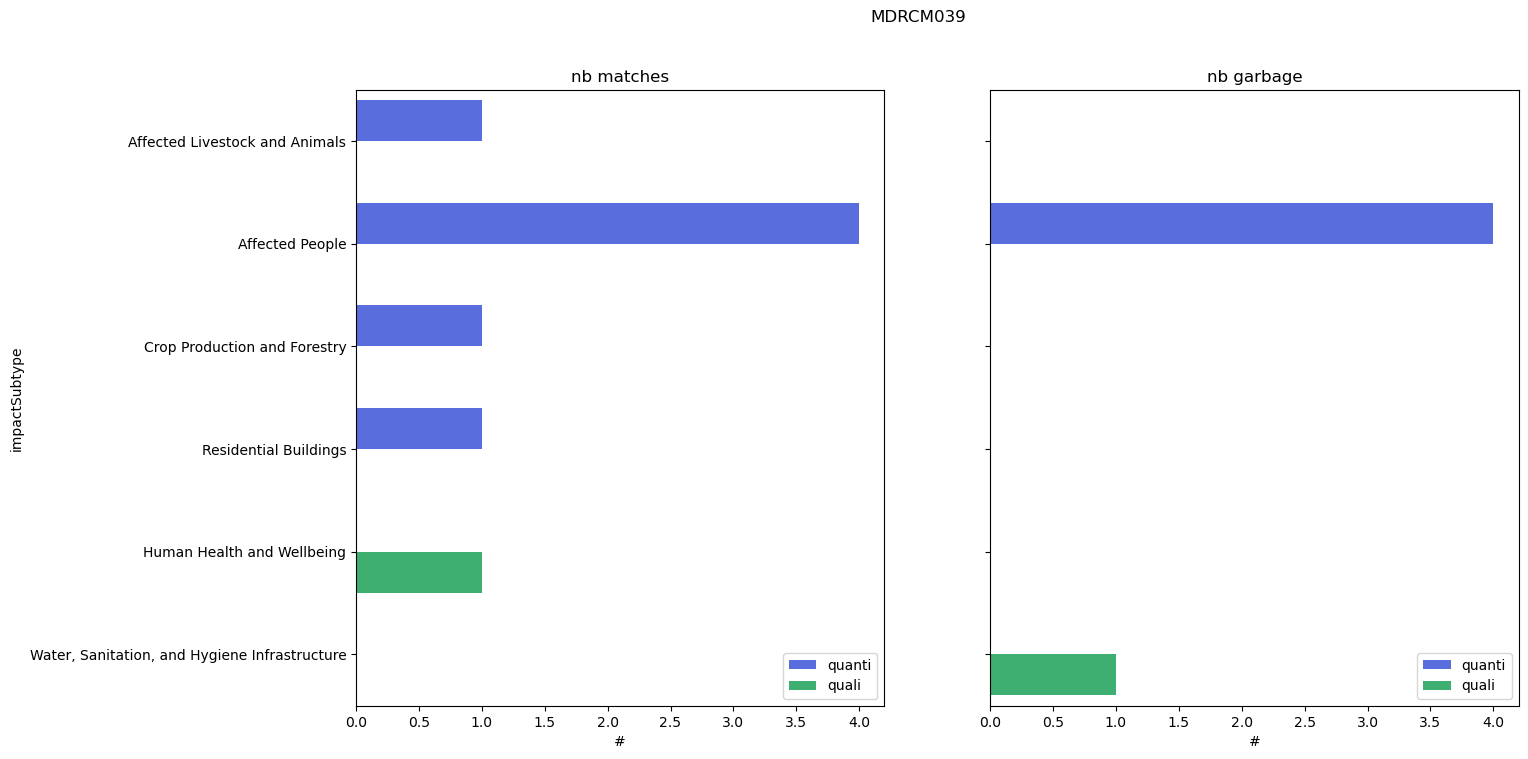

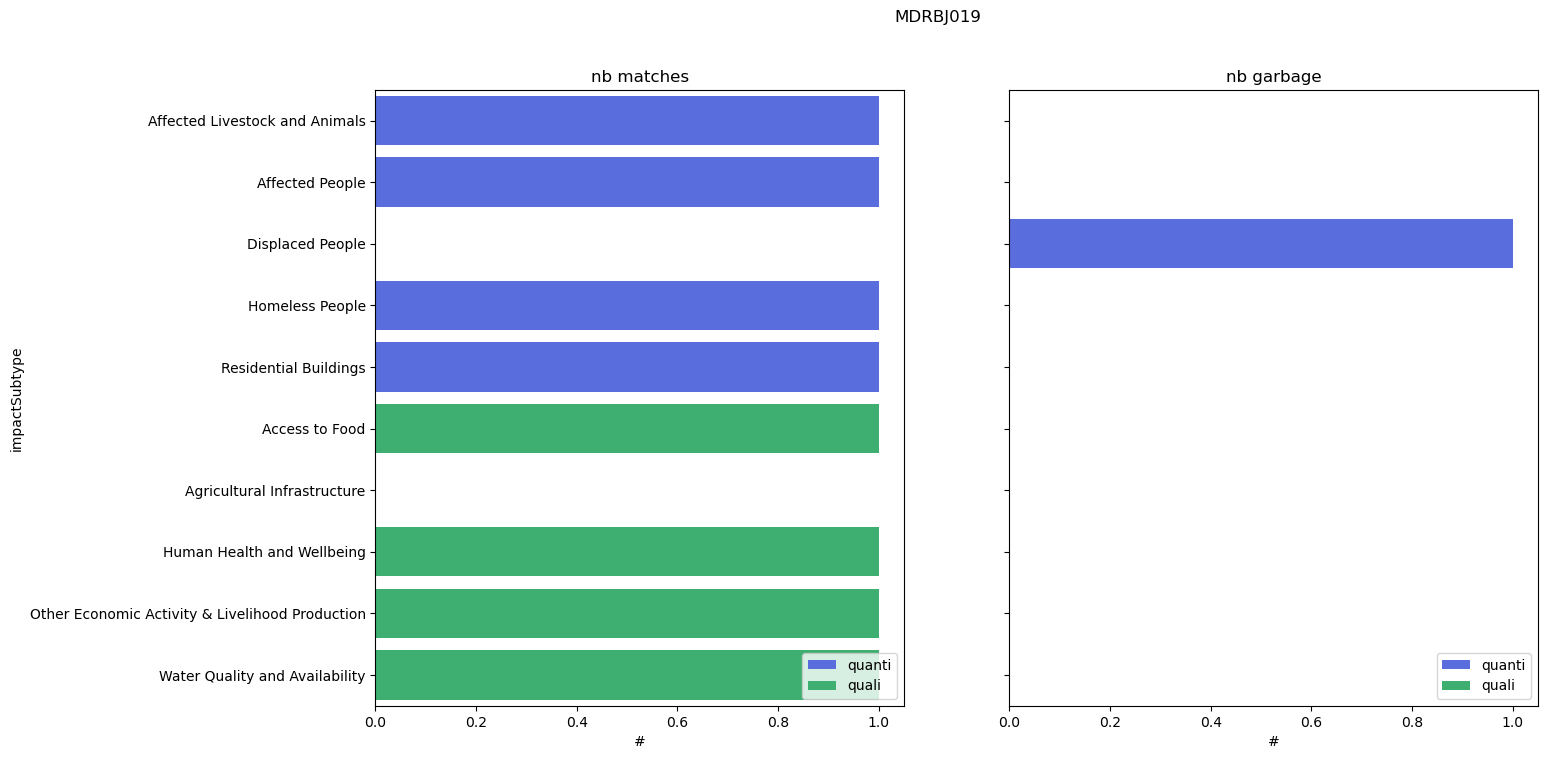

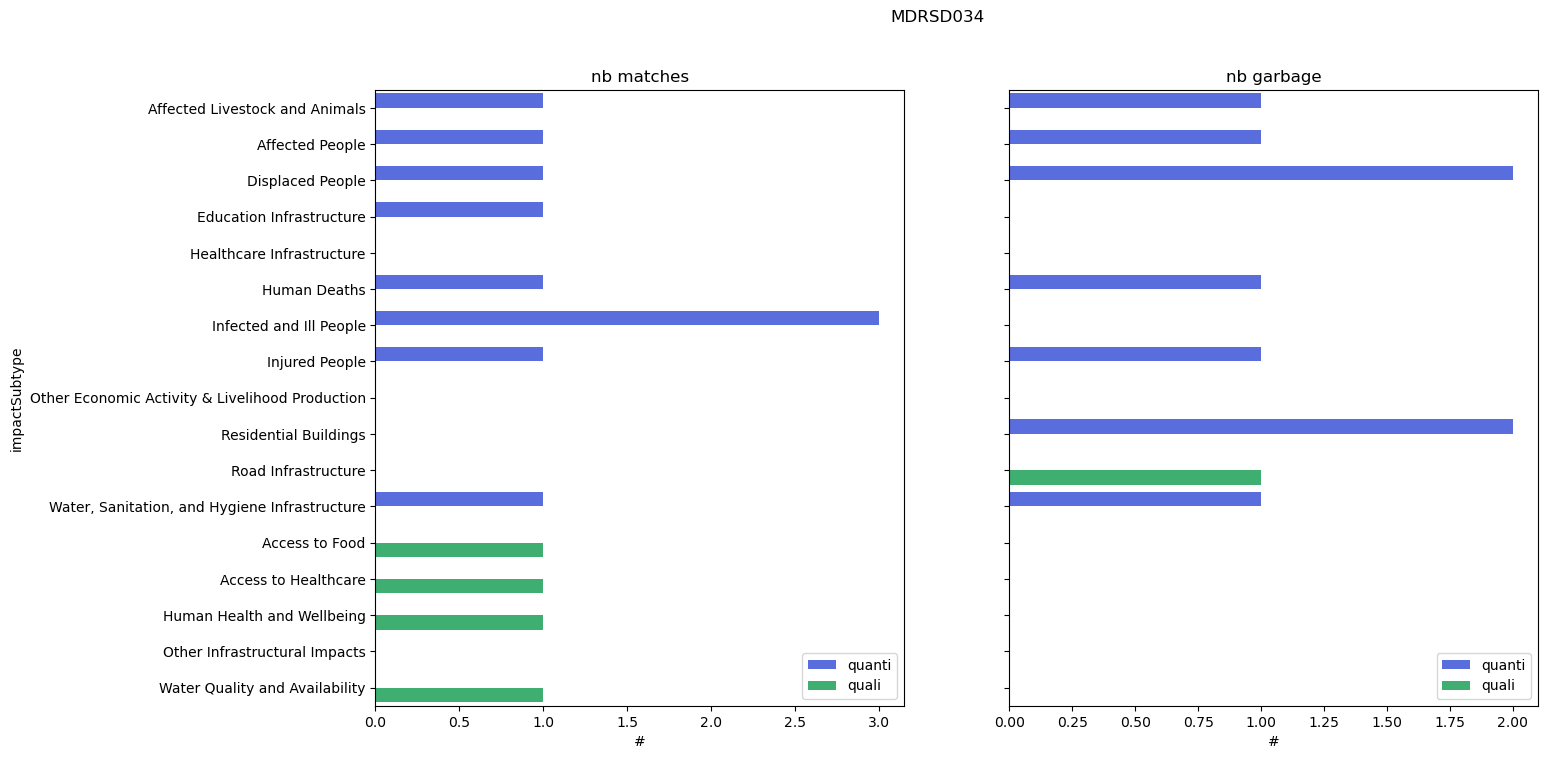

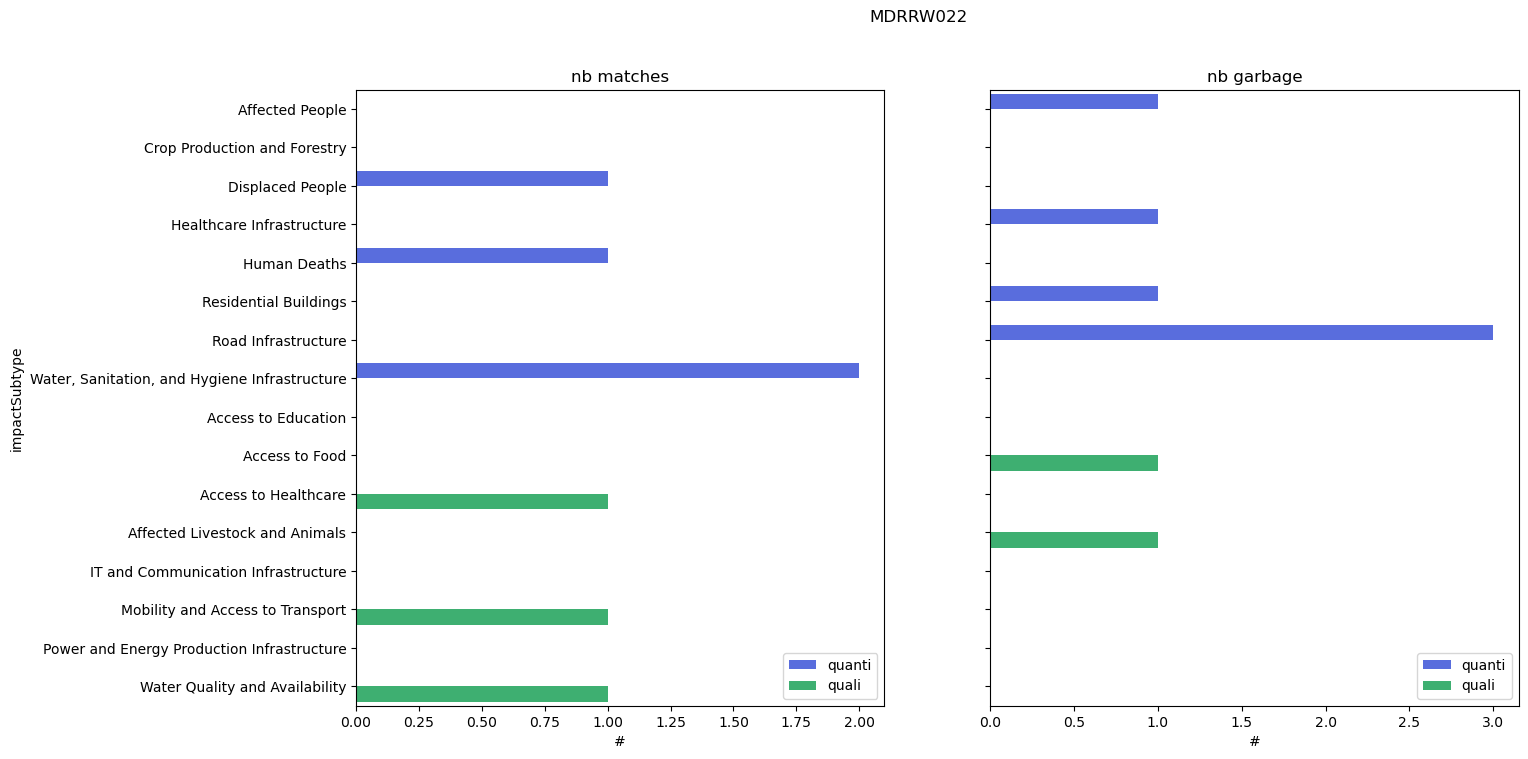

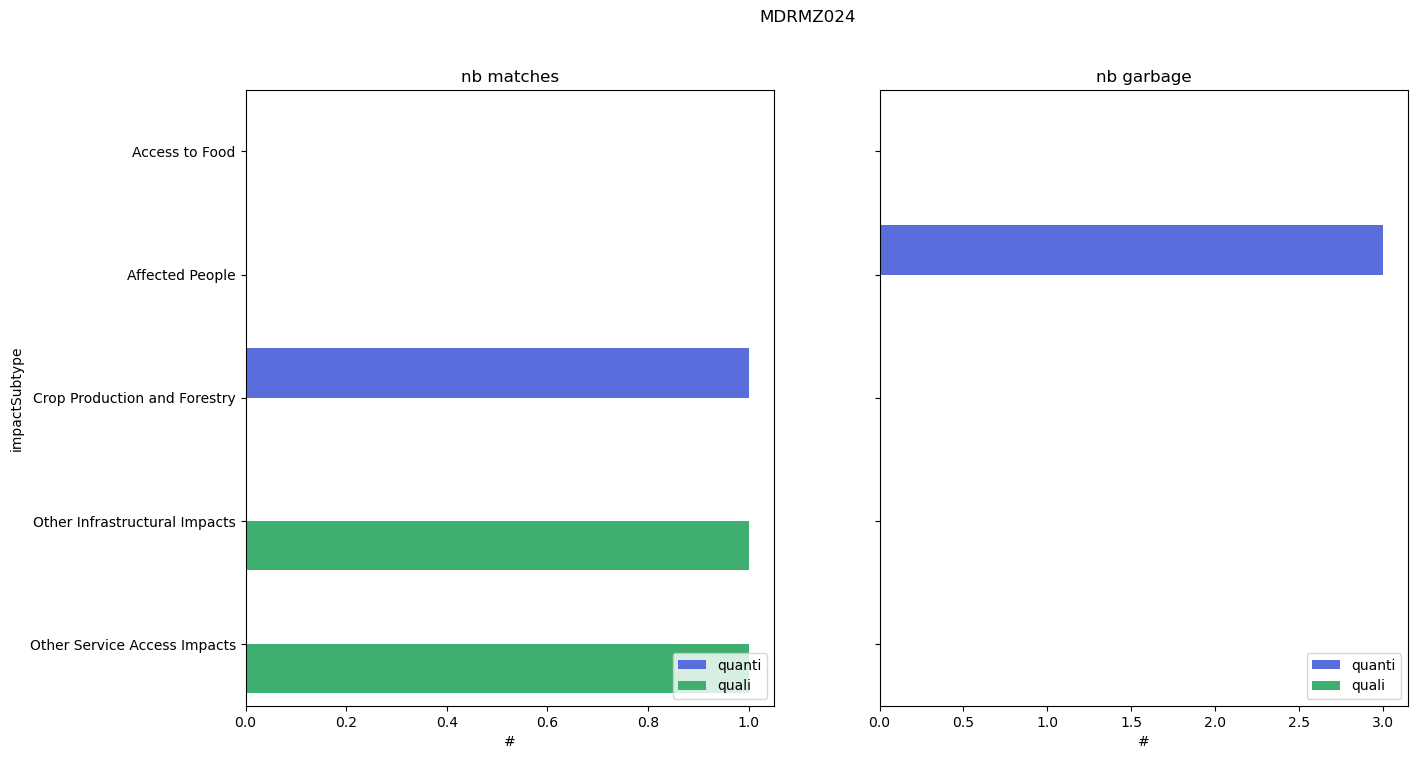

In [ ]:
#coverage vs garbage per impactSubtype for each report
appeals = labelled_df.appealCode.unique()
value_vars = ["nb matches", "nb garbage"]#["coverage matches", "garbage"]#["nb matches", "nb garbage"]
label = "#"
yvar="impactSubtype"
#fig, axes = plt.subplots(len(appeals), 2, figsize=(15, 10), sharey=True)
#choose plotting cols
subplot_col = "match"#"quanti""match"
hue_col = "quanti"#"quanti""match"
palette_rel = ["#E61F04", "#f46c6c","#177093","#27a4d6"]
palette_rel = ["#435EF3", "#2bc26f","#435EF3", "#2bc26f", "#435EF3", "#2bc26f"]

for i, appeal in enumerate(appeals):
    ext_appeal = extracted_df_filter[extracted_df_filter["appealCode"] == appeal]
    lab_appeal = labelled_df_filter[labelled_df_filter["appealCode"] == appeal]
    matched_appeal = matched_df_filter2[matched_df_filter2["appealCode"] == appeal]
    coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype").reset_index(drop=False, names=["impactSubtype"])
    plot_df = coverage_df_match_appeal_subtype.melt(id_vars=[yvar, "quanti"], value_vars=value_vars, var_name="match", value_name="value")
    fig, axes = plot_coverage_match_v2(plot_df, subplot_col, hue_col, yvar=yvar, value_col="value", palette=palette_rel, add_avg=add_avg)
    [ax.set_xlabel(label) for ax in axes]
    fig.suptitle(appeal)

In [9]:
appeal="MDRCM039"
ext_appeal = extracted_df[extracted_df["appealCode"] == appeal]
lab_appeal = labelled_df[labelled_df["appealCode"] == appeal]
matched_appeal = matched_df[matched_df["appealCode"] == appeal]
coverage_df_match_appeal_subtype = make_coverage_accuracy_df(ext_appeal, lab_appeal, matched_appeal, group_key="impactSubtype").reset_index(drop=False, names=["impactSubtype"])

In [10]:
print_match(matched_appeal[matched_appeal["impactSubtype"]=="Affected People"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,...,startYear_sim,startMonth_sim,startDay_sim,endYear_sim,endMonth_sim,endDay_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
54,MDRCM039,Affected People,Affected People,158620.0,400.0,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Ndoukoula district'],1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.902439,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
55,MDRCM039,Affected People,Affected People,158620.0,200.0,people,people,"['Logone et Chari division', 'Mayo Danay divis...",['Mokolo district'],1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.902439,['The provisional report consolidated by the w...,"['Notably, in the Diamar division, where Ndouk..."
59,MDRCM039,Affected People,Affected People,75000.0,75000.0,people,people,['Blangoua'],['Blangoua'],1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.975610,"['In the Logone et Chari division, the affecte...","['In the Logone et Chari division, the affecte..."
60,MDRCM039,Affected People,Affected People,43000.0,43000.0,people,people,['Makary'],['Makary'],1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.926829,"['In the Logone et Chari division, the affecte...","['In the Logone et Chari division, the affecte..."
61,MDRCM039,Affected People,Affected People,9000.0,43000.0,people,people,['Zina'],['Makary'],1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.902439,"['In the Logone et Chari division, the affecte...","['In the Logone et Chari division, the affecte..."
62,MDRCM039,Affected People,Affected People,9000.0,9000.0,people,people,['Zina'],['Zina'],1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.902439,"['In the Logone et Chari division, the affecte...","['In the Logone et Chari division, the affecte..."
63,MDRCM039,Affected People,Affected People,18000.0,18000.0,people,people,['Maga'],['Maga'],1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.975610,"['In the Mayo Danay division: - Maga with 18,0...","['In the Logone et Chari division, the affecte..."
64,MDRCM039,Affected People,Affected People,13000.0,13000.0,people,people,['Yagoua'],['Yagoua'],1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.975610,['In the Mayo Danay division: - Yagoua with ne...,"['In the Logone et Chari division, the affecte..."
65,MDRCM039,Affected People,Affected People,400.0,400.0,people,people,['Ndoukoula district'],['Ndoukoula district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.951220,['Ndoukoula district has reported over 400 peo...,"['Notably, in the Diamar division, where Ndouk..."
66,MDRCM039,Affected People,Affected People,200.0,200.0,people,people,['Mokolo district'],['Mokolo district'],1.0,...,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.951220,"['Mokolo district, has recorded nearly 200 aff...","['Notably, in the Diamar division, where Ndouk..."


In [110]:
matched_appeal[matched_appeal["impactSubtype"]=="Affected People"]#[["appealCode","impactSubtype", "impactSubtype_matched", "impactValue", "impactValue_matched", "impactUnit", "impactUnit_matched", "location", "location_matched", "impactSubtype_sim", "impactUnit_sim", "geometry_sim","hazards_sim","match_sim","valueAnnotation", "annotation_matched"]]

,impactSubtype,impactValue,impactValueMin,impactValueMax,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,country,location,...,endMonth_sim,endDay_sim,impactSubtype_sim,impactUnit_sim,geometry_sim,match_sim,impactValue_error,quanti,impactValue_sim,appealType
53,Affected People,158620.0,NaN,NaN,exact,people,['The provisional report consolidated by the w...,0,['Cameroon'],"['Logone et Chari division', 'Mayo Danay divis...",...,0.0,1.0,1.0,1.0,1.000000,0.925000,395.550000,quanti,0.0,DREF Operation
57,Affected People,75000.0,NaN,NaN,exact,people,"['In the Logone et Chari division, the affecte...",0,['Cameroon'],['Blangoua'],...,1.0,1.0,1.0,1.0,1.000000,0.975000,0.000000,quanti,1.0,DREF Operation
58,Affected People,43000.0,NaN,NaN,exact,people,"['In the Logone et Chari division, the affecte...",0,['Cameroon'],['Makary'],...,0.0,0.0,1.0,1.0,1.000000,0.925000,0.000000,quanti,1.0,DREF Operation
59,Affected People,9000.0,NaN,NaN,exact,people,"['In the Logone et Chari division, the affecte...",0,['Cameroon'],['Zina'],...,0.0,0.0,1.0,1.0,1.000000,0.925000,3.777778,quanti,0.0,DREF Operation
60,Affected People,18000.0,NaN,NaN,exact,people,"['In the Mayo Danay division: - Maga with 18,0...",0,['Cameroon'],['Maga'],...,1.0,1.0,1.0,1.0,1.000000,0.975000,0.000000,quanti,1.0,DREF Operation
61,Affected People,13000.0,NaN,NaN,exact,people,['In the Mayo Danay division: - Yagoua with ne...,0,['Cameroon'],['Yagoua'],...,1.0,1.0,1.0,1.0,1.000000,0.975000,0.000000,quanti,1.0,DREF Operation
62,Affected People,400.0,NaN,NaN,exact,people,['Ndoukoula district has reported over 400 peo...,0,['Cameroon'],['Ndoukoula district'],...,1.0,1.0,1.0,1.0,0.027631,0.951382,21.500000,quanti,0.0,DREF Operation
63,Affected People,200.0,NaN,NaN,exact,people,"['Mokolo district, has recorded nearly 200 aff...",0,['Cameroon'],['Mokolo district'],...,1.0,1.0,1.0,1.0,0.039769,0.951988,89.000000,quanti,0.0,DREF Operation


In [94]:
coverage_df_match_appeal_subtype

,impactSubtype,nb labelled,nb extracted,coverage,nb matches,coverage matches,nb garbage,garbage,quanti
0,Affected People,21,1,4.761905,1,4.761905,0,0.0,quanti
1,Human Deaths,1,1,100.000000,1,100.000000,0,0.0,quanti
2,Injured People,1,1,100.000000,1,100.000000,0,0.0,quanti
3,Displaced People,1,0,0.000000,0,0.000000,0,0.0,quali
4,Informal Settlements,1,0,0.000000,0,0.000000,0,0.0,quali
5,Other Economic Activity & Livelihood Production,1,0,0.000000,0,0.000000,0,0.0,quali
6,Residential Buildings,2,0,0.000000,0,0.000000,0,0.0,quali
7,Water Quality and Availability,1,1,100.000000,1,100.000000,0,0.0,quali
8,"Water, Sanitation, and Hygiene Infrastructure",1,1,100.000000,1,100.000000,0,0.0,quali


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_68870/2555611310.py:10: UserWarning: set_ticklabels() should only be used with a fixed number 

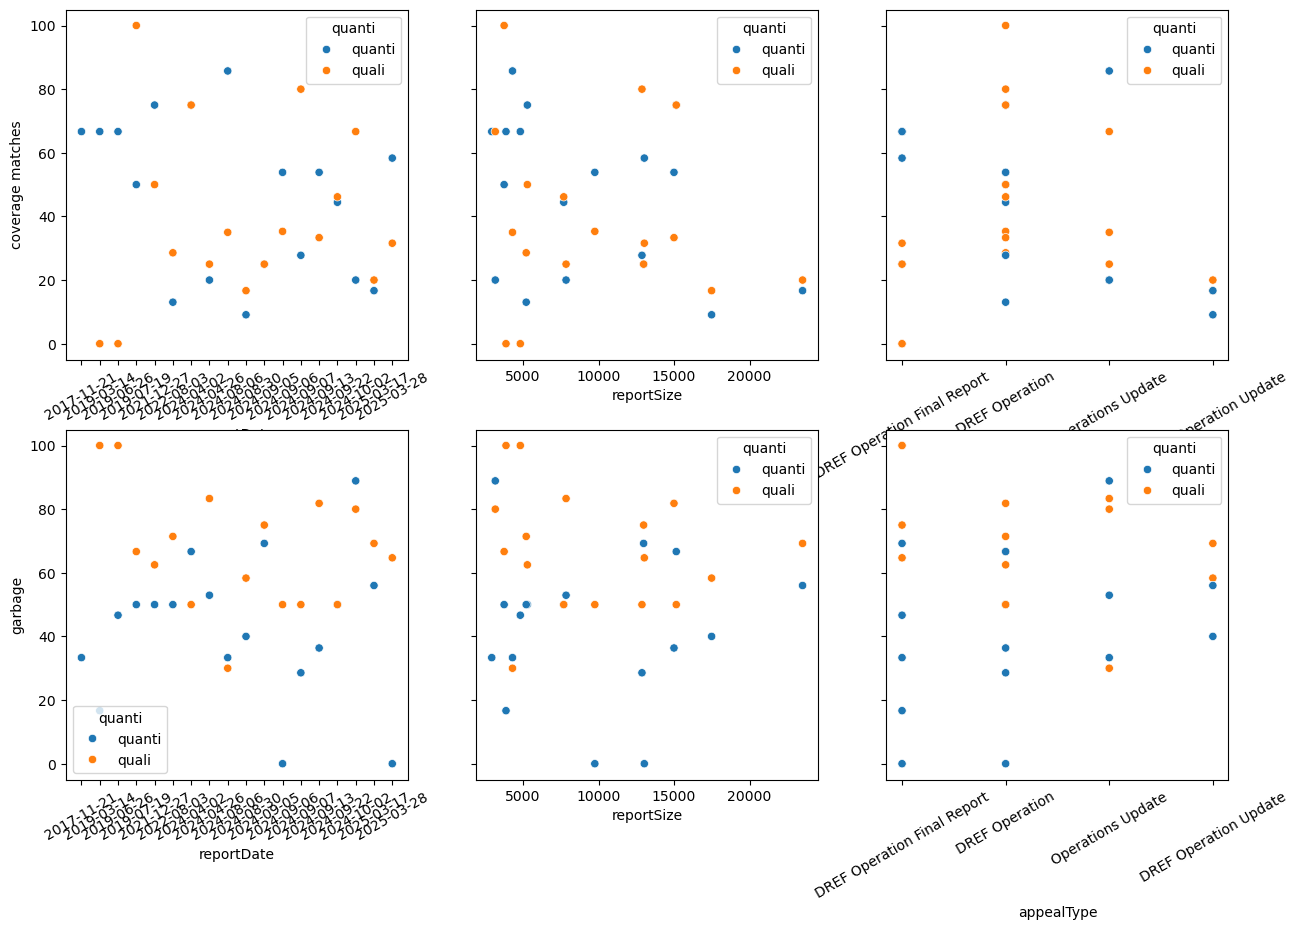

In [37]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [119]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 184 extracted, 336 labelled, 100 correct matches, 84 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 100 correct matches, 84 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 102 correct matches, 82 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 102 correct matches, 82 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 103 correct matches, 81 garbage matches
Overall average quali: 164 extracted, 174 labelled, 0 correct matches, 164 garbage matches
Overall average quanti: 184 extracted, 336 labelled, 103 correct matches, 81 gar

<Axes: >

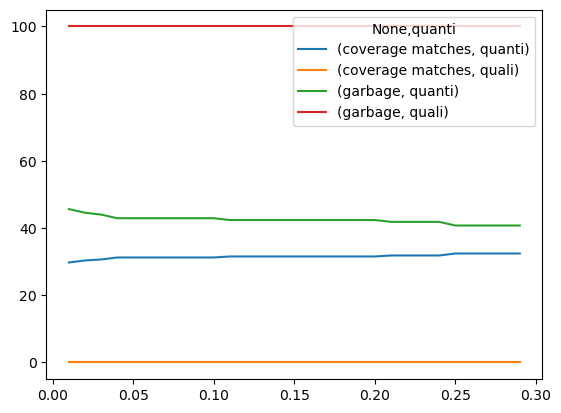

In [120]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

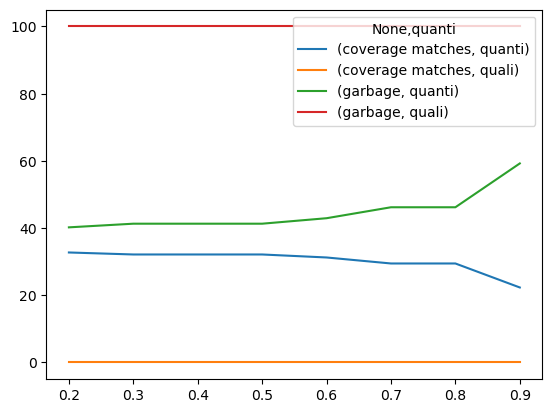

In [122]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [40]:
from importlib import reload
from src import utils
reload(utils)
from src.utils import print_match
print_match(matched_df[matched_df["match_sim"]<0.6])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,impactUnit_sim,geometry_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
4,MDRBD022,Informal settlements,Affected People,690.000000,2176519.0,informal settlements,people,[],[],0.0,0.0,1.000000,1.000000,0.225000,['No. of temporary shelter opened 690'],['DREF operation n MDRBD022 Glide n FL-2019-00...
5,MDRBD022,Other Infrastructural Impacts,Affected People,410077.947974,2176519.0,EUR,people,[],[],0.0,0.0,1.000000,1.000000,0.275000,"['DREF allocated: CHF 452,439']",['DREF operation n MDRBD022 Glide n FL-2019-00...
7,MDRBD022,Other Infrastructural Impacts,Affected People,21.000000,2176519.0,districts,people,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",[],0.0,0.0,0.999197,1.000000,0.274960,['According to National disaster response coor...,['DREF operation n MDRBD022 Glide n FL-2019-00...
8,MDRBD022,Other Infrastructural Impacts,Affected People,124.000000,2176519.0,sub-district,people,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...",[],0.0,0.0,0.999197,0.707107,0.267638,['No. of sub-district affected 124'],['DREF operation n MDRBD022 Glide n FL-2019-00...
9,MDRBD022,Other Infrastructural Impacts,Affected People,776.000000,2176519.0,union,people,[],[],0.0,0.0,1.000000,1.000000,0.225000,['No. of union affected 776'],['DREF operation n MDRBD022 Glide n FL-2019-00...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,MDRZM022,Affected Livestock and Animals,Affected Livestock and Animals,NaN,NaN,null,nan,"['Southern Province', 'Gwembe', 'Sinazongwe', ...","['North-Western province', 'Southern province'...",1.0,0.0,0.642168,1.000000,0.582108,['Pasture is drying up making is difficult for...,['Page 1 / 21 DREF Operation Zambia Drought 20...
599,MDRZM022,Human Health and Wellbeing,Water Quality and Availability,NaN,NaN,null,nan,"['Southern Province', 'Gwembe', 'Sinazongwe', ...","['North-Western province', 'Southern province'...",0.0,0.0,0.568388,1.000000,0.228419,['The health implications of the current droug...,['Page 1 / 21 DREF Operation Zambia Drought 20...
600,MDRZM022,Human Health and Wellbeing,"Access to Water, Sanitation, and Hygiene",NaN,NaN,null,nan,"['Southern Province', 'Gwembe', 'Sinazongwe', ...","['North-Western province', 'Southern province'...",0.0,0.0,0.568388,1.000000,0.228419,['The health implications of the current droug...,['Page 1 / 21 DREF Operation Zambia Drought 20...
601,MDRZM022,Human Health and Wellbeing,Affected Livestock and Animals,NaN,NaN,null,nan,"['Southern Province', 'Gwembe', 'Sinazongwe', ...","['North-Western province', 'Southern province'...",0.0,0.0,0.568388,1.000000,0.228419,['The health implications of the current droug...,['Page 1 / 21 DREF Operation Zambia Drought 20...


In [123]:
print_match(matched_df[(matched_df["match_sim"]<0.6) & (matched_df["appealCode"]=="MDRMZ024")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,impactUnit_sim,geometry_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
247,MDRMZ024,Other Economic Activity & Livelihood Production,Other Economic Activity & Livelihood Production,5.325948e+06,3.0,EUR,% of unknown,"['Tete', 'Gaza', 'Manica', 'Inhambane']",[],1.0,0.0,0.39694,1.000000,0.507168,['Funding requirements (CHF): CHF 5 million th...,['1 OPERATION UPDATE Mozambique | Drought Emer...
248,MDRMZ024,Other Economic Activity & Livelihood Production,Other Economic Activity & Livelihood Production,9.586706e+05,3.0,EUR,% of unknown,[],[],1.0,0.0,1.00000,1.000000,0.536585,['Federation-wide DREF amount initially alloca...,['1 OPERATION UPDATE Mozambique | Drought Emer...
249,MDRMZ024,Crop Production and Forestry,Crop Production and Forestry,4.000000e+01,6900.0,%,km**2 of crop production and forestry,['central and northern zones'],"['Tete', 'Gaza', 'Manica', 'Inhambane']",1.0,0.0,0.39694,1.000000,0.555948,['Prices were 40% higher or more compared to l...,['1 OPERATION UPDATE Mozambique | Drought Emer...
250,MDRMZ024,Other Human Impacts,Affected People,6.116500e+04,61165.0,people,people,[],[],0.0,1.0,1.00000,0.707107,0.529442,"['Number of people being assisted: 61,165 peop...",['1 OPERATION UPDATE Mozambique | Drought Emer...
251,MDRMZ024,Access to Food,Access to Food,3.000000e+00,2700000.0,%,people,"['Tete', 'Gaza', 'Manica', 'Inhambane']",[],1.0,0.0,0.39694,1.000000,0.531558,"[""Mozambique National Institute of Statistics'...",['1 OPERATION UPDATE Mozambique | Drought Emer...


In [55]:
print_match(matched_df[(matched_df["impactSubtype"]=="Informal Settlements")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,impactUnit_sim,geometry_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
204,MDRKE058,Informal Settlements,Other Infrastructural Impacts,NaN,NaN,null,null,['Nairobi'],[],0.0,1.0,0.010277,0.707107,0.468192,['The floods have also hit the capital in resi...,"['Destroyed infrastructure, health and educati..."
205,MDRKE058,Informal Settlements,Healthcare Infrastructure,NaN,NaN,null,null,['Nairobi'],[],0.0,1.0,0.010277,0.707107,0.468192,['The floods have also hit the capital in resi...,"['Destroyed infrastructure, health and educati..."
206,MDRKE058,Informal Settlements,Education Infrastructure,NaN,NaN,null,null,['Nairobi'],[],0.0,1.0,0.010277,0.707107,0.468192,['The floods have also hit the capital in resi...,"['Destroyed infrastructure, health and educati..."
207,MDRKE058,Informal Settlements,Affected Livestock and Animals,NaN,NaN,null,null,['Nairobi'],[],0.0,1.0,0.010277,0.707107,0.468192,['The floods have also hit the capital in resi...,['Communities reported significant loss of liv...
208,MDRKE058,Informal Settlements,Crop Production and Forestry,NaN,NaN,null,null,['Nairobi'],[],0.0,1.0,0.010277,0.707107,0.468192,['The floods have also hit the capital in resi...,['Communities reported significant loss of liv...
209,MDRKE058,Informal Settlements,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,['Nairobi'],[],0.0,1.0,0.010277,0.707107,0.468192,['The floods have also hit the capital in resi...,['Communities reported significant loss of liv...
446,MDRSD034,Informal Settlements,Water Quality and Availability,NaN,NaN,null,null,"['Tokar', 'Port Sudan', 'Aqeeq', 'Red Sea Stat...",[],0.0,1.0,1.000000,0.577350,0.589434,['The situation directly affected displaced in...,"['Since August, the Ministry of health has str..."
507,MDRYE011,Informal Settlements,Affected People,247.0,1085.0,informal settlements,people,[],['Hadramout'],0.0,0.0,1.000000,0.500000,0.262500,['Based on YRCS and shelter cluster flood trac...,['Based on YRCS and shelter cluster flood trac...


In [56]:
print_match(matched_df[(matched_df["impactSubtype"]=="Other Infrastructural Impacts")])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,impactUnit_sim,geometry_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
12,MDRBD022,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Kurigram district', 'Gaibandha district', 'L...",1.0,1.0,0.999197,0.707107,0.967638,['embankments have been damaged and inundated ...,['It is also reported that embankments have be...
13,MDRBD022,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,null,"['Kurigram', 'Gaibandha', 'Lalmonirhat', 'Chat...","['Gaddimari area', 'Lalmonirhats Hatibandha']",1.0,1.0,0.999197,0.707107,0.967638,['embankments have been damaged and inundated ...,['of union affected 776 Emergency Plan of Acti...
79,MDRCM039,Other Infrastructural Impacts,Other Infrastructural Impacts,NaN,NaN,null,unknown,"['Logone et Chari division', 'Mayo Danay divis...","['Mayo Danay division', 'Yagoua']",1.0,0.0,1.000000,1.000000,0.600000,"['Several water points were contaminated, and ...",['The peak of the floods was recorded on Augus...
99,MDRCN006,Other Infrastructural Impacts,Residential Buildings,NaN,NaN,null,homes,"['Sichuan', 'Gansu Province', 'Deyang', 'Miany...","['Sichuan', 'southeast region of Gansu']",0.0,0.0,0.095318,0.707107,0.147444,['The Provincial Disaster Reduction Commission...,"['According to this rapid assessment, heavy ra..."
141,MDRDZ011,Other Infrastructural Impacts,Other Economic Activity & Livelihood Production,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,1.0,0.185453,1.000000,0.509273,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
142,MDRDZ011,Other Infrastructural Impacts,Other Service Access Impacts,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,1.0,0.185453,1.000000,0.509273,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
143,MDRDZ011,Other Infrastructural Impacts,Mobility and Access to Transport,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,1.0,0.185453,1.000000,0.509273,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
144,MDRDZ011,Other Infrastructural Impacts,Access to Power and Energy,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,1.0,0.185453,1.000000,0.509273,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
145,MDRDZ011,Other Infrastructural Impacts,Water Quality and Availability,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,1.0,0.185453,1.000000,0.509273,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...
146,MDRDZ011,Other Infrastructural Impacts,Access to Food,NaN,NaN,null,null,['Béchar'],"['Béchar', 'Elbayadh', 'Beni Abbes', 'Tamanras...",0.0,1.0,0.185453,1.000000,0.509273,"['critical infrastructure, including 4 bridges...",['DREF Operation Algeria Flood 2024 Bechar App...


In [42]:
matched_df[matched_df["match_sim"]<0.6]["impactUnit"].value_counts()

impactUnit
null                                     188
people                                    21
EUR                                       16
percent                                   10
businesses                                 3
informal settlements                       3
km**2 of crop production and forestry      2
vehicles                                   2
crop production and forestry               2
children                                   2
other buildings                            1
facilities                                 1
women                                      1
landsides                                  1
% of buildings                             1
rivers                                     1
children under 5                           1
subsidences                                1
%                                          1
fatality                                   1
critical facilities                        1
parcels                                    1

In [41]:
print_match(matched_df_filter[matched_df_filter["appealCode"]=="MDRRW022"])

,appealCode,impactSubtype,impactSubtype_matched,impactValue,impactValue_matched,impactUnit,impactUnit_matched,location,location_matched,impactSubtype_sim,impactUnit_sim,geometry_sim,hazards_sim,match_sim,valueAnnotation,annotation_matched
330,MDRRW022,Human Deaths,Human Deaths,137.0,137.0,people,people,"['Western Province', 'Northern Province', 'Sou...",[],1.0,1.0,0.625783,1.0,0.831289,['137 people died'],"['From 1 to 6 May, Rwanda experienced continuo..."
332,MDRRW022,Displaced People,Displaced People,38422.0,38000.0,people,people,"['Western Province', 'Northern Province', 'Sou...",[],1.0,1.0,0.625783,1.0,0.931289,"['7,684 households were evacuated (with over 3...","['From 1 to 6 May, Rwanda experienced continuo..."
335,MDRRW022,"Water, Sanitation, and Hygiene Infrastructure","Water, Sanitation, and Hygiene Infrastructure",5740.0,5740.0,WASH structures,WASH structures,[],[],1.0,1.0,1.000000,1.0,0.950000,"['The damages to approximately 5,740 latrines ...","['From 1 to 6 May, Rwanda experienced continuo..."
337,MDRRW022,"Water, Sanitation, and Hygiene Infrastructure","Water, Sanitation, and Hygiene Infrastructure",6.0,6.0,WASH structures,WASH structures,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",[],1.0,1.0,1.000000,1.0,0.950000,['6 Water Treatment Plants flooded and not fun...,"['From 1 to 6 May, Rwanda experienced continuo..."
379,MDRRW022,Mobility and Access to Transport,Mobility and Access to Transport,NaN,NaN,null,null,"['Western Province', 'Northern Province', 'Sou...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",1.0,1.0,0.625783,1.0,0.931289,['Some of the market supply system was particu...,"['From 1 to 6 May, Rwanda experienced continuo..."
385,MDRRW022,Access to Healthcare,Access to Healthcare,NaN,NaN,null,null,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...","['Muhanga', 'Ngororero', 'Mukamira', 'Rubenger...",1.0,1.0,1.000000,1.0,0.950000,['Health teams provided first aid in flood-aff...,"['From 1 to 6 May, Rwanda experienced continuo..."
386,MDRRW022,Water Quality and Availability,Water Quality and Availability,NaN,NaN,null,null,"['Rubavu', 'Nyarugenge', 'Cyondo', 'Nyagatare'...",[],1.0,1.0,1.000000,1.0,0.875000,['Several water systems were affected by the f...,"['From 1 to 6 May, Rwanda experienced continuo..."


In [43]:
extracted_df[extracted_df["appealCode"]=="MDRMZ024"][["impactUnit", "flag_percent"]]

,impactUnit,flag_percent
62,people,False
63,people,False
64,people,False
65,km**2 of crop production and forestry,False
66,null,False
67,EUR,False
68,EUR,False
69,%,True
70,people,False
71,null,False


In [39]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_percent,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,False,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report


In [40]:
labelled_df[labelled_df["appealCode"]=="MDRRW022"]

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location,...,flag_percent,locationLowestAdmin,geocoding_country_flag,geocoding_osm_flag,locationOsm,locationPolygon,iso3_code,geometry,quanti,appealType
474,2024-09-05,Affected People,51905.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
475,2024-09-05,Human Deaths,137.0,people,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
476,2024-09-05,Residential Buildings,5472.0,homes,exact,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
477,2024-09-05,Water Quality and Availability,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
478,2024-09-05,Road Infrastructure,NaN,null,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
479,2024-09-05,"Water, Sanitation, and Hygiene Infrastructure",NaN,WASH structures,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
480,2024-09-05,Crop Production and Forestry,10.0,km**2 of crop production and forestry,approx,10.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
481,2024-09-05,Affected Livestock and Animals,NaN,affected animals,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quali,DREF Operation Final Report
482,2024-09-05,Displaced People,38000.0,people,approx,38000.0,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],[],...,False,ADM_0,0,0,['Rwanda'],['Rwanda'],['RWA'],"MULTIPOLYGON (((29.04054 -2.74413, 29.04022 -2...",quanti,DREF Operation Final Report
483,2024-09-05,Residential Buildings,4933.0,homes,approx,NaN,NaN,"['From 1 to 6 May, Rwanda experienced continuo...",['Rwanda'],"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...",...,False,ADM_1,0,0,"['Rubavu', 'Nyabihu', 'Ngororero', 'Karongi', ...","['Western Province', 'Western Province', 'West...",['RWA'],"MULTIPOLYGON (((29.0405 -2.73948, 29.0405 -2.7...",quanti,DREF Operation Final Report


## Coverage by subtype

In [149]:
# coverage grouped by impactSubtype
def make_coverage_subtype_df(extracted_df, labelled_df):
    coverages_by_subtype = {}
    n_ext = len(extracted_df)
    n_lab = len(labelled_df)
    for subtype, group_ext in extracted_df.groupby("impactSubtype"):
        group_lab = labelled_df[labelled_df["impactSubtype"] == subtype]
        coverage = len(group_ext)/len(group_lab) if len(group_lab) > 0 else np.nan
        coverage_rel_ext = len(group_ext) / n_ext
        coverage_rel_lab = len(group_lab) / n_lab
        print(f"{subtype}: {len(group_ext)} extracted, {len(group_lab)} labelled, {coverage} coverage")
        coverages_by_subtype[subtype] = (len(group_ext), len(group_lab), coverage, coverage_rel_ext, coverage_rel_lab)
    return pd.DataFrame(coverages_by_subtype, index=["nb extracted","nb labelled","coverage", "coverage_rel_ext", "coverage_rel_lab"]).T

coverage_subtype_df = make_coverage_subtype_df(extracted_df, labelled_df)

Access to Education: 4 extracted, 2 labelled, 2.0 coverage
Access to Food: 26 extracted, 10 labelled, 2.6 coverage
Access to Healthcare: 17 extracted, 6 labelled, 2.8333333333333335 coverage
Access to Power and Energy: 4 extracted, 4 labelled, 1.0 coverage
Access to Water, Sanitation, and Hygiene: 17 extracted, 4 labelled, 4.25 coverage
Affected Livestock and Animals: 16 extracted, 14 labelled, 1.1428571428571428 coverage
Affected People: 44 extracted, 106 labelled, 0.41509433962264153 coverage
Agricultural Infrastructure: 14 extracted, 2 labelled, 7.0 coverage
Crop Production and Forestry: 20 extracted, 33 labelled, 0.6060606060606061 coverage
Displaced People: 19 extracted, 38 labelled, 0.5 coverage
Education Infrastructure: 6 extracted, 11 labelled, 0.5454545454545454 coverage
Healthcare Infrastructure: 6 extracted, 12 labelled, 0.5 coverage
Homeless People: 14 extracted, 9 labelled, 1.5555555555555556 coverage
Human Deaths: 15 extracted, 26 labelled, 0.5769230769230769 coverage
Hum

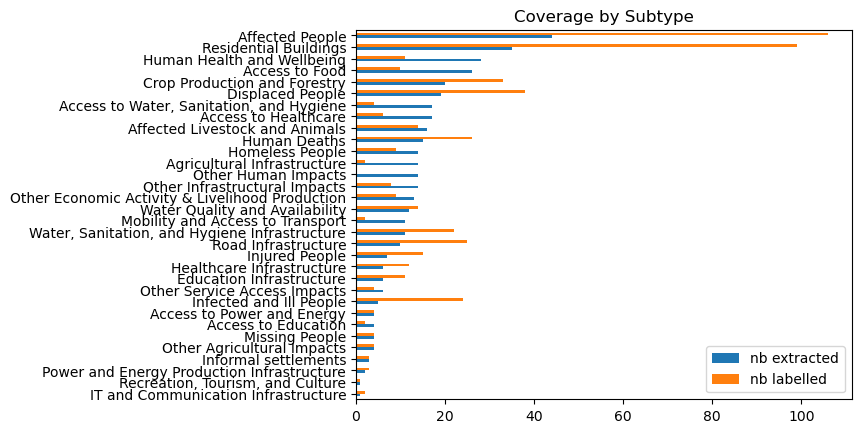

In [24]:
ax = coverage_subtype_df[["nb extracted", "nb labelled"]].sort_values("nb extracted", ascending=True).plot(kind="barh")
ax.set_title("Coverage by Subtype")
fig = ax.get_figure()
#fig.savefig(DATA_FIGURE / f"coverage_by_subtype_{dt.datetime.today().strftime('%d%m%y')}.png", bbox_inches="tight", dpi=300)

Access to Education: 4 extracted, 2 labelled, 2.0 coverage
Access to Food: 26 extracted, 10 labelled, 2.6 coverage
Access to Healthcare: 17 extracted, 6 labelled, 2.8333333333333335 coverage
Access to Power and Energy: 4 extracted, 4 labelled, 1.0 coverage
Access to Water, Sanitation, and Hygiene: 17 extracted, 4 labelled, 4.25 coverage
Affected Livestock and Animals: 16 extracted, 14 labelled, 1.1428571428571428 coverage
Affected People: 44 extracted, 106 labelled, 0.41509433962264153 coverage
Agricultural Infrastructure: 14 extracted, 2 labelled, 7.0 coverage
Crop Production and Forestry: 20 extracted, 33 labelled, 0.6060606060606061 coverage
Displaced People: 19 extracted, 38 labelled, 0.5 coverage
Education Infrastructure: 6 extracted, 11 labelled, 0.5454545454545454 coverage
Healthcare Infrastructure: 6 extracted, 12 labelled, 0.5 coverage
Homeless People: 14 extracted, 9 labelled, 1.5555555555555556 coverage
Human Deaths: 15 extracted, 26 labelled, 0.5769230769230769 coverage
Hum

Text(0.5, 0.98, 'Coverage by subtype')

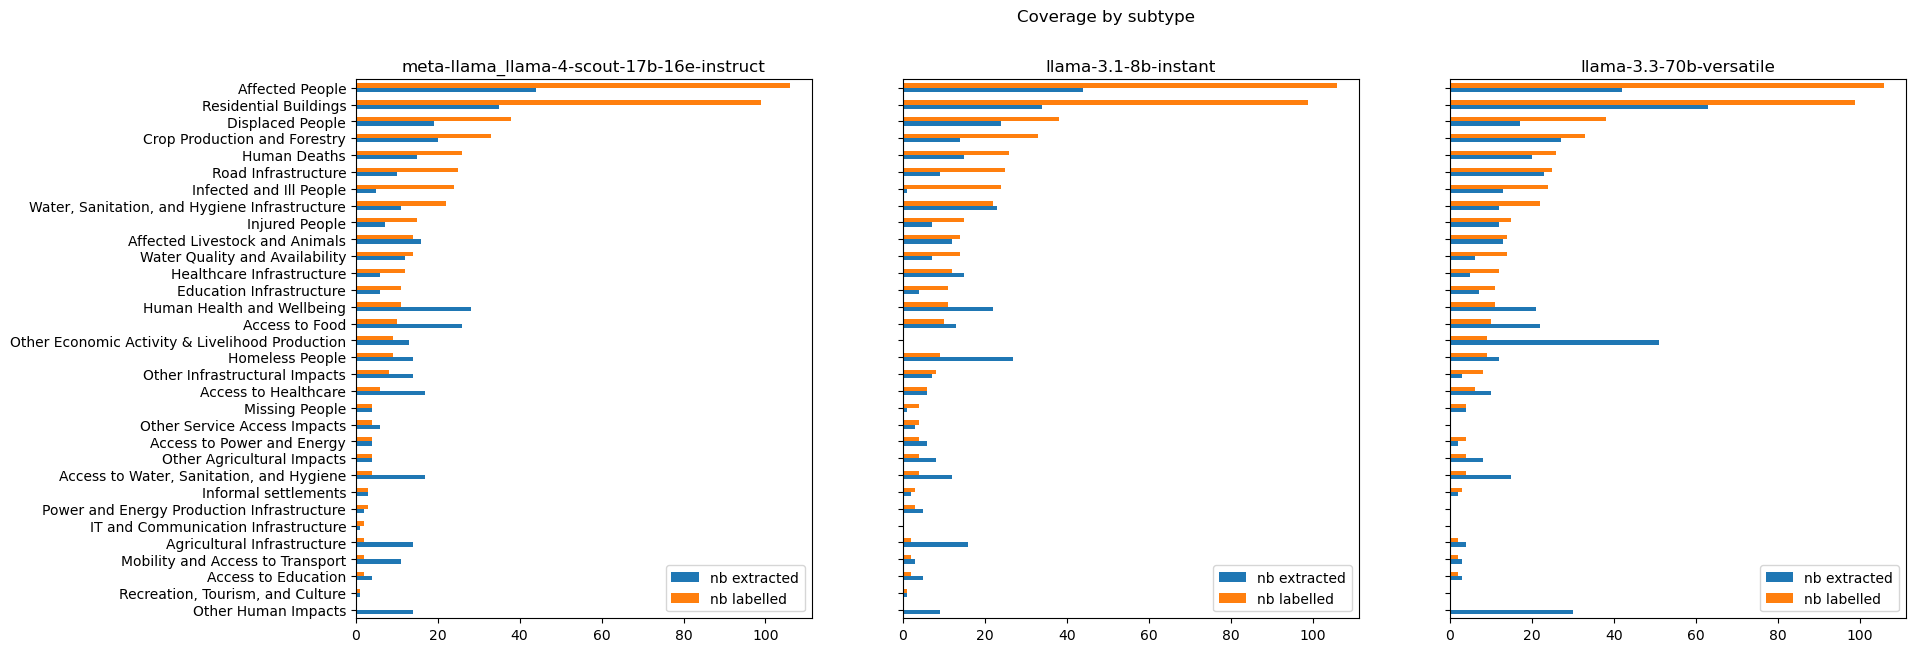

In [36]:
# compare different models
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
res_savename_ext1 = f"post_processed_labelled_reports_{models[0]}_v230925"
res_savename_ext2 = f"post_processed_labelled_reports_{models[1]}_v250925"
res_savename_ext3 = f"post_processed_labelled_reports_{models[2]}_v250925"

#load geocoded data
extracted_df1 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext1+".csv"))
extracted_df2 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext2+".csv"))
extracted_df3 = pd.read_csv(DATA_OUT_PROC / (res_savename_ext3+".csv"))

coverage_subtype_df1 = make_coverage_subtype_df(extracted_df1, labelled_df)
coverage_subtype_df2 = make_coverage_subtype_df(extracted_df2, labelled_df)
coverage_subtype_df3 = make_coverage_subtype_df(extracted_df3, labelled_df)

fig, axes = plt.subplots(1, 3 ,figsize=(20,7), sharey=False, sharex=True)
label = coverage_subtype_df1[["nb extracted", "nb labelled"]].sort_values("nb labelled", ascending=True).index
coverage_subtype_df1[["nb extracted", "nb labelled"]].reindex(label).plot(kind="barh", ax=axes[0])
coverage_subtype_df2[["nb extracted", "nb labelled"]].reindex(label).plot(kind="barh", ax=axes[1])
coverage_subtype_df3[["nb extracted", "nb labelled"]].reindex(label).plot(kind="barh", ax=axes[2])

axes[0].set_title(models[0])
axes[1].set_title(models[1])
axes[2].set_title(models[2])

axes[1].set_yticklabels([])
axes[2].set_yticklabels([])

fig.suptitle("Coverage by subtype")

In [20]:
#spatial coverage by report
spatial_cov_appeal_lab = labelled_df.groupby("appealCode").locationLowestAdmin.value_counts().unstack()
spatial_cov_appeal_ext = extracted_df.groupby("appealCode").locationLowestAdmin.value_counts().unstack()
spatial_cov_appeal_df = pd.concat([spatial_cov_appeal_lab, spatial_cov_appeal_ext], keys=["labelled","extracted"],axis=1, join="inner")

<Axes: title={'center': 'Extracted'}, ylabel='appealCode'>

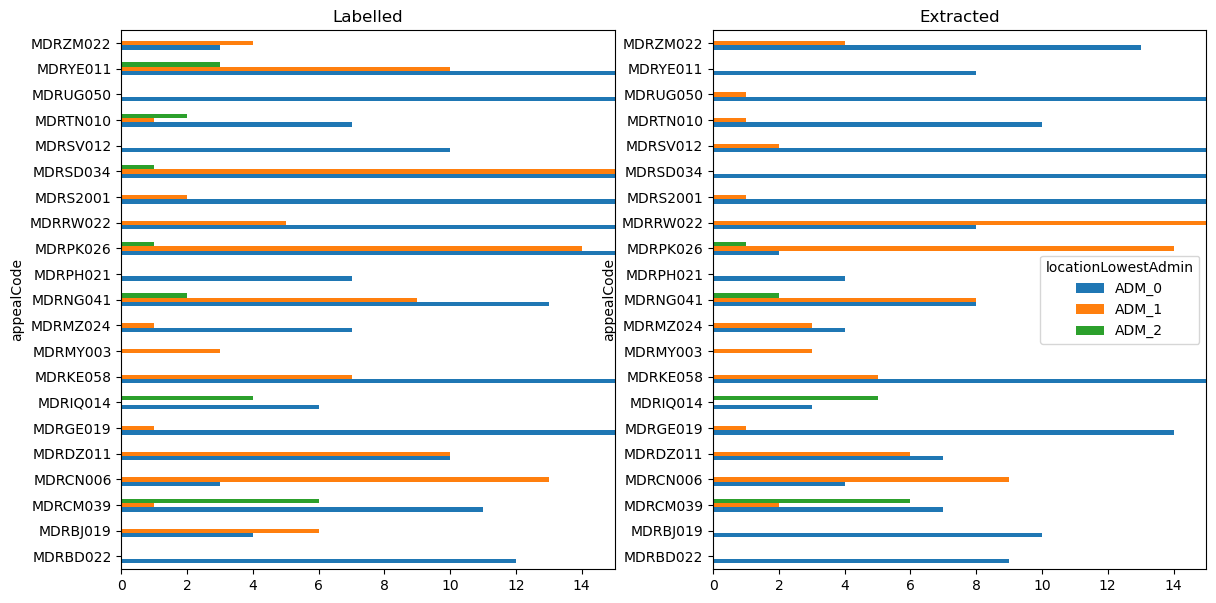

In [21]:
fix, axes = plt.subplots(1,2, figsize=(14, 7))
spatial_cov_appeal_df["labelled"].plot(kind="barh", ax=axes[0], legend=False,title="Labelled", xlim=[0,15])
spatial_cov_appeal_df["extracted"].plot(kind="barh", ax=axes[1], title="Extracted",xlim=[0,15])

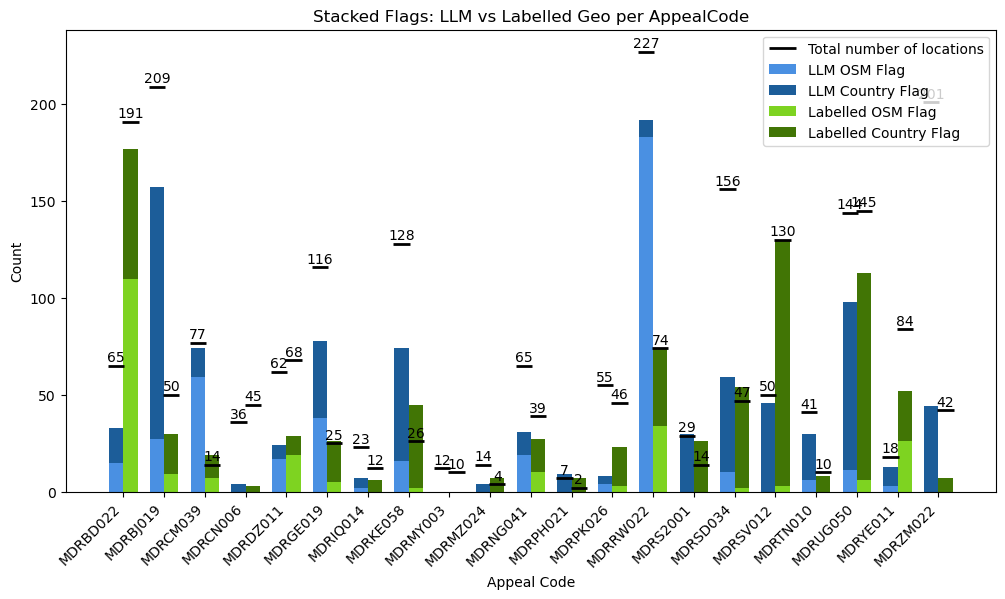

In [23]:
# Compute number of locations per row
for df in [extracted_df, labelled_df]:
    df['num_locations'] = df['location'].apply(
        lambda x: len(x) if isinstance(x, (list, tuple)) else (0 if pd.isna(x) else 1)
    )

# Group by appealCode
grouped_llm = extracted_df.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

grouped_labelled = labelled_df.groupby('appealCode').agg({
    'num_locations': 'sum',
    'geocoding_osm_flag': 'sum',
    'geocoding_country_flag': 'sum'
}).reset_index()

# Set bar width and positions
bar_width = 0.35
x = np.arange(len(grouped_llm['appealCode']))

fig, ax = plt.subplots(figsize=(12,6))

# Colors
llm_colors = ['#4A90E2', '#1C5D99']       # Light blue, dark blue
labelled_colors = ['#7ED321', '#417505']  # Light green, dark green

# LLM bars
ax.bar(x - bar_width/2, grouped_llm['geocoding_osm_flag'], bar_width, color=llm_colors[0], label='LLM OSM Flag')
ax.bar(x - bar_width/2, grouped_llm['geocoding_country_flag'], bar_width,
       bottom=grouped_llm['geocoding_osm_flag'], color=llm_colors[1], label='LLM Country Flag')

# Labelled bars
ax.bar(x + bar_width/2, grouped_labelled['geocoding_osm_flag'], bar_width, color=labelled_colors[0], label='Labelled OSM Flag')
ax.bar(x + bar_width/2, grouped_labelled['geocoding_country_flag'], bar_width,
       bottom=grouped_labelled['geocoding_osm_flag'], color=labelled_colors[1], label='Labelled Country Flag')

# Plot total reports as lines
for i in range(len(x)):
    ax.hlines(y=grouped_llm['num_locations'][i], xmin=i - bar_width/2 - 0.2, xmax=i - bar_width/2 + 0.2,
              color='black', lw=2, label='Total number of locations' if i==0 else "")
    ax.text(i - bar_width/2, grouped_llm['num_locations'][i] + 0.5, str(grouped_llm['num_locations'][i]),
            ha='center', va='bottom', fontsize=10)

    ax.hlines(y=grouped_labelled['num_locations'][i], xmin=i + bar_width/2 - 0.2, xmax=i + bar_width/2 + 0.2,
              color='black', lw=2)
    ax.text(i + bar_width/2, grouped_labelled['num_locations'][i] + 0.5, str(grouped_labelled['num_locations'][i]),
            ha='center', va='bottom', fontsize=10)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(grouped_llm['appealCode'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_xlabel('Appeal Code')
ax.set_title('Stacked Flags: LLM vs Labelled Geo per AppealCode')
ax.legend()
fig.savefig(DATA_FIGURE /'counts_flags_appealCode_llm-labelled.png', dpi=300, bbox_inches='tight', transparent=True)